<a href="https://colab.research.google.com/github/manu93jadon/CI-CD-Project/blob/master/IPL_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Download dataset and load in df

In [1]:
import pandas as pd
import urllib.request
url = 'https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/158/850/original/IPL_2008-2024.csv?1760202529'
output_file = 'ipldata.csv'

# Download the file
urllib.request.urlretrieve(url, output_file)
print(f"Downloaded data to {output_file}")

ipl_df = pd.read_csv(output_file)

Downloaded data to ipldata.csv


#Import Section

In [2]:
import numpy as np

# 1 ) Data Preprocessing & Feature Engineering
Prepare the IPL dataset through cleaning, exploratory analysis, and creation of meaningful new features that capture match dynamics.

In [3]:
ipl_df.shape

(1095, 20)

In [4]:
ipl_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   int64  
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [5]:
ipl_df.describe()

,id,season,result_margin,target_runs,target_overs
count,1.095000e+03,1095.000000,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,2016.126027,17.259294,165.684066,19.759341
std,3.677402e+05,4.946940,21.787444,33.427048,1.581108
min,3.359820e+05,2008.000000,1.000000,43.000000,5.000000
25%,5.483315e+05,2012.000000,6.000000,146.000000,20.000000
50%,9.809610e+05,2016.000000,8.000000,166.000000,20.000000
75%,1.254062e+06,2021.000000,20.000000,187.000000,20.000000
max,1.426312e+06,2024.000000,146.000000,288.000000,20.000000


In [6]:
# Check for missing values in each column
missing_values=ipl_df.isnull().sum().sort_values(ascending=False)
print(missing_values)

method             1074
city                 51
result_margin        19
player_of_match       5
winner                5
target_runs           3
target_overs          3
id                    0
date                  0
season                0
venue                 0
match_type            0
toss_decision         0
toss_winner           0
team2                 0
team1                 0
result                0
super_over            0
umpire1               0
umpire2               0
dtype: int64


In [7]:
#Check for unique values in each column
unique_values=ipl_df.nunique().sort_values(ascending=False)
print(unique_values)

id                 1095
date                823
player_of_match     291
target_runs         170
result_margin        98
umpire1              62
umpire2              62
venue                58
city                 36
toss_winner          19
team1                19
team2                19
winner               19
season               17
target_overs         15
match_type            8
result                4
toss_decision         2
super_over            2
method                1
dtype: int64


In [8]:
ipl_df.value_counts("venue")

,count
venue,
Eden Gardens,77
Wankhede Stadium,73
M Chinnaswamy Stadium,65
Feroz Shah Kotla,60
"Rajiv Gandhi International Stadium, Uppal",49
"MA Chidambaram Stadium, Chepauk",48
Sawai Mansingh Stadium,47
Dubai International Cricket Stadium,46
"Wankhede Stadium, Mumbai",45


In [9]:
#Checking city along with Venue to confirm if some venue names are duplicated here
ipl_df.groupby("venue")["city"].value_counts("venue").sort_values(ascending=False)

,,proportion
venue,city,
Arun Jaitley Stadium,Delhi,1.00
"Arun Jaitley Stadium, Delhi",Delhi,1.00
Barabati Stadium,Cuttack,1.00
"Barsapara Cricket Stadium, Guwahati",Guwahati,1.00
"Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",Lucknow,1.00
Brabourne Stadium,Mumbai,1.00
"Brabourne Stadium, Mumbai",Mumbai,1.00
Buffalo Park,East London,1.00
De Beers Diamond Oval,Kimberley,1.00


## Observation 1- Multiple Venues are listed duplicated, some are renames and some are duplicated due to city name along with their names, we will standardise this.

In [10]:
ipl_df.value_counts("city")

,count
city,
Mumbai,173
Kolkata,93
Delhi,90
Chennai,85
Hyderabad,77
Bangalore,65
Chandigarh,61
Jaipur,57
Pune,51


## Observation 2 - Some City names are duplicated like Bengaluru and Banglore, we will standardise this as well.

In [11]:
ipl_df.value_counts("team1")

,count
team1,
Royal Challengers Bangalore,135
Chennai Super Kings,128
Mumbai Indians,123
Kolkata Knight Riders,121
Rajasthan Royals,101
Kings XI Punjab,92
Sunrisers Hyderabad,86
Delhi Daredevils,85
Delhi Capitals,41


## Observation 3 - Duplicates are caused here by:
  

*   Some team name changes like Delhi Daredevils to Delhi Capitals, Royal Challengers Bengalore  to Royal Challengers Bengaluru
*   Rising Pune Supergiant and Rising Pune Supergiants , minor spelling change

In [12]:
ipl_df.value_counts("match_type")

,count
match_type,
League,1029
Final,17
Qualifier 1,14
Qualifier 2,14
Eliminator,11
Semi Final,6
Elimination Final,3
3rd Place Play-Off,1


In [13]:
ipl_df.value_counts("method")

,count
method,
D/L,21


## Observation 4- Only one value of method - D/L, we will rather create one column like DL_used - Yes or No

In [14]:
# Null values analysis
null_city_rows = ipl_df[ipl_df['city'].isnull()]
null_method_rows = ipl_df[ipl_df['method'].isnull()]
null_winner_rows = ipl_df[ipl_df['winner'].isnull()]
null_result_margin_rows = ipl_df[ipl_df['result_margin'].isnull()]
null_player_of_match_rows = ipl_df[ipl_df['player_of_match'].isnull()]
null_target_runs_rows = ipl_df[ipl_df['target_runs'].isnull()]
null_target_overs_rows = ipl_df[ipl_df['target_overs'].isnull()]

display("1 ) null_city_rows")
display(null_city_rows)

display("2 ) null_method_rows")
display(null_method_rows)

display("3 ) null_winner_rows")
display(null_winner_rows)

display("4) null_result_margin_rows")
display(null_result_margin_rows)

display("5 ) null_player_of_match_rows")
display(null_player_of_match_rows)

display("6 ) null_target_runs_rows")
display(null_target_runs_rows)

display("7 ) null_target_overs_rows")
display(null_target_overs_rows)

'1 ) null_city_rows'

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
399,729281,2014,NaN,2014-04-17,League,YS Chahal,Sharjah Cricket Stadium,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,8.0,146.0,20.0,N,NaN,Aleem Dar,S Ravi
402,729287,2014,NaN,2014-04-19,League,PA Patel,Dubai International Cricket Stadium,Royal Challengers Bangalore,Mumbai Indians,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,7.0,116.0,20.0,N,NaN,Aleem Dar,AK Chaudhary
403,729289,2014,NaN,2014-04-19,League,JP Duminy,Dubai International Cricket Stadium,Kolkata Knight Riders,Delhi Daredevils,Kolkata Knight Riders,bat,Delhi Daredevils,wickets,4.0,167.0,20.0,N,NaN,Aleem Dar,VA Kulkarni
404,729291,2014,NaN,2014-04-20,League,GJ Maxwell,Sharjah Cricket Stadium,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,field,Kings XI Punjab,wickets,7.0,192.0,20.0,N,NaN,BF Bowden,M Erasmus
406,729295,2014,NaN,2014-04-22,League,GJ Maxwell,Sharjah Cricket Stadium,Kings XI Punjab,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Kings XI Punjab,runs,72.0,194.0,20.0,N,NaN,M Erasmus,S Ravi
407,729297,2014,NaN,2014-04-23,League,RA Jadeja,Dubai International Cricket Stadium,Rajasthan Royals,Chennai Super Kings,Rajasthan Royals,field,Chennai Super Kings,runs,7.0,141.0,20.0,N,NaN,HDPK Dharmasena,RK Illingworth
408,729299,2014,NaN,2014-04-24,League,CA Lynn,Sharjah Cricket Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,2.0,151.0,20.0,N,NaN,Aleem Dar,VA Kulkarni
409,729301,2014,NaN,2014-04-25,League,AJ Finch,Dubai International Cricket Stadium,Sunrisers Hyderabad,Delhi Daredevils,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,runs,4.0,185.0,20.0,N,NaN,M Erasmus,S Ravi
410,729303,2014,NaN,2014-04-25,League,MM Sharma,Dubai International Cricket Stadium,Chennai Super Kings,Mumbai Indians,Mumbai Indians,bat,Chennai Super Kings,wickets,7.0,142.0,20.0,N,NaN,BF Bowden,M Erasmus
413,729309,2014,NaN,2014-04-27,League,M Vijay,Sharjah Cricket Stadium,Delhi Daredevils,Mumbai Indians,Mumbai Indians,bat,Delhi Daredevils,wickets,6.0,126.0,20.0,N,NaN,Aleem Dar,VA Kulkarni


'2 ) null_method_rows'

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma


'3 ) null_winner_rows'

...

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak
511,829813,2015,Bangalore,2015-05-17,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,NaN,no result,NaN,188.0,20.0,N,NaN,HDPK Dharmasena,K Srinivasan
744,1178424,2019,Bengaluru,2019-04-30,League,NaN,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,63.0,5.0,N,NaN,NJ Llong,UV Gandhe
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,NaN,no result,NaN,NaN,NaN,N,NaN,AK Chaudhary,NA Patwardhan


'6 ) null_target_runs_rows'

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,NaN,no result,NaN,NaN,NaN,N,NaN,AK Chaudhary,NA Patwardhan


'7 ) null_target_overs_rows'

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,NaN,no result,NaN,NaN,NaN,N,NaN,AK Chaudhary,NA Patwardhan


## Observation 5 - Missing Values Explanation:


> a) Method
- 1074 values missing - This is expected as if match was played interrupted ,like rain, only then sometime D/L is applied, else method is null , what we can do maybe  change column to yes/no kind of column, like if_dl.



> b ) city

- 51 values missing - Data Error - Matches were Played in 2014 and 2020 in Sharjah , Abudhabi and Dubai International UAE, we can fill missing values as per city mapping
> c ) result_margin
- 19 values missing - Matches without result - either "Tie"(14) or "no result" (5) won't have any result margin. We can split into runs and wickets columns with NaN where not applicable, and no-result rows would be only be kept in the master dataset and filtered per analysis.
> d ) player_of_match
- 5 rows - "No result rows"
> e ) winner
- 5 rows - "No result rows" same as above      
>f ) target_runs
- "No result rows" where no overs could be played at all
>g ) target_over
- "No result rows" where no overs could be played at all

## Standardising Columns and Fixing Missing Values

In [15]:
import pandas as pd

# 1. Standardise differently listed Venue Names
standard_venues = {
    # Bengaluru
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",
    "M Chinnaswamy Stadium, Bengaluru": "M Chinnaswamy Stadium",

    # Chennai
    "MA Chidambaram Stadium, Chepauk": "MA Chidambaram Stadium",
    "MA Chidambaram Stadium, Chepauk, Chennai": "MA Chidambaram Stadium",

    # Delhi
    "Arun Jaitley Stadium, Delhi": "Arun Jaitley Stadium",
    "Feroz Shah Kotla": "Arun Jaitley Stadium",

    # Mumbai & Navi Mumbai
    "Wankhede Stadium, Mumbai": "Wankhede Stadium",
    "Brabourne Stadium, Mumbai": "Brabourne Stadium",
    "Dr DY Patil Sports Academy, Mumbai": "Dr DY Patil Sports Academy",

    # Chandigarh / Mohali
    "Punjab Cricket Association Stadium, Mohali": "Punjab Cricket Association IS Bindra Stadium",
    "Punjab Cricket Association IS Bindra Stadium, Mohali": "Punjab Cricket Association IS Bindra Stadium",
    "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh": "Punjab Cricket Association IS Bindra Stadium",

    # Hyderabad
    "Rajiv Gandhi International Stadium, Uppal": "Rajiv Gandhi International Stadium",
    "Rajiv Gandhi International Stadium, Uppal, Hyderabad": "Rajiv Gandhi International Stadium",

    # Pune
    "Maharashtra Cricket Association Stadium, Pune": "Maharashtra Cricket Association Stadium",
    "Subrata Roy Sahara Stadium": "Maharashtra Cricket Association Stadium",

    # Ahmedabad
    "Narendra Modi Stadium, Ahmedabad": "Narendra Modi Stadium",
    "Sardar Patel Stadium, Motera": "Narendra Modi Stadium",

    # Kolkata
    "Eden Gardens, Kolkata": "Eden Gardens",

    # Jaipur
    "Sawai Mansingh Stadium, Jaipur": "Sawai Mansingh Stadium",

    # Dharamsala
    "Himachal Pradesh Cricket Association Stadium, Dharamsala": "Himachal Pradesh Cricket Association Stadium",

    # Visakhapatnam
    "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam": "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium",

    # Abu Dhabi
    "Zayed Cricket Stadium, Abu Dhabi": "Sheikh Zayed Stadium",
    "Zayed Cricket Stadium": "Sheikh Zayed Stadium",

    #Comma Separated
    "Barsapara Cricket Stadium, Guwahati": "Barsapara Cricket Stadium",
    "Vidarbha Cricket Association Stadium, Jamtha": "Vidarbha Cricket Association Stadium",
    "Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow": "Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium"
}

# 2. Fix the city inconsistencies alongside the venue clean-up
standard_cities = {
    "Bangalore": "Bengaluru",
    "Navi Mumbai": "Mumbai"
}

# Step A: Clean up the trailing/leading whitespaces
ipl_df['venue'] = ipl_df['venue'].str.strip()
ipl_df['city'] = ipl_df['city'].str.strip()

# Step B: Map the duplicates to their standard names
ipl_df['venue'] = ipl_df['venue'].replace(standard_venues)
ipl_df['city'] = ipl_df['city'].replace(standard_cities)

# Step C: Fix the specific PCA Mohali city classification (from Chandigarh to Mohali)
ipl_df.loc[ipl_df['venue'] == 'Punjab Cricket Association IS Bindra Stadium', 'city'] = 'Mohali'
# Step D: Verifying unique counts now
cleaned_grouped = ipl_df.groupby("venue")["city"].value_counts().sort_values(ascending=False)
print(cleaned_grouped)


venue                                                               city          
Wankhede Stadium                                                    Mumbai            118
M Chinnaswamy Stadium                                               Bengaluru          94
Eden Gardens                                                        Kolkata            93
Arun Jaitley Stadium                                                Delhi              90
MA Chidambaram Stadium                                              Chennai            85
Rajiv Gandhi International Stadium                                  Hyderabad          77
Punjab Cricket Association IS Bindra Stadium                        Mohali             61
Sawai Mansingh Stadium                                              Jaipur             57
Maharashtra Cricket Association Stadium                             Pune               51
Dr DY Patil Sports Academy                                          Mumbai             37
Sheikh Zayed Stad

In [16]:
# 1. Fix Team names inconsistencies  - mapping dictionary for IPL franchises:
standard_teams = {
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Rising Pune Supergiants": "Rising Pune Supergiant",
}
# 1. Clean team name columns
ipl_df[['team1', 'team2', 'toss_winner', 'winner']] = ipl_df[['team1', 'team2', 'toss_winner', 'winner']].apply(lambda x: x.str.strip().replace(standard_teams))

# 2. Get value counts now
print(ipl_df[['team1', 'team2', 'toss_winner', 'winner']].apply(pd.Series.value_counts).sort_values(by='team1', ascending=False))



                             team1  team2  toss_winner  winner
Royal Challengers Bengaluru    144    111          121     123
Chennai Super Kings            128    110          122     138
Delhi Capitals                 126    126          130     115
Mumbai Indians                 123    138          143     144
Punjab Kings                   123    123          109     112
Kolkata Knight Riders          121    130          122     131
Rajasthan Royals               101    120          120     112
Sunrisers Hyderabad             86     96           88      88
Deccan Chargers                 39     36           43      29
Pune Warriors                   23     23           20      12
Lucknow Super Giants            23     21           19      24
Gujarat Titans                  21     24           22      28
Gujarat Lions                   16     14           15      13
Rising Pune Supergiant          14     16           13      15
Kochi Tuskers Kerala             7      7            8 

In [17]:
# Initialize the venue to city mapping dictionary
venue_to_city_map = {}

# Manually add mappings for the UAE venues that have all missing cities in 2014 or 2020
venue_to_city_map['Sharjah Cricket Stadium'] = 'Sharjah'
venue_to_city_map['Dubai International Cricket Stadium'] = 'Dubai'
venue_to_city_map['Sheikh Zayed Stadium'] = 'Abu Dhabi'

# 2. Fill missing city values using the map
ipl_df['city'] = ipl_df['city'].fillna(ipl_df['venue'].map(venue_to_city_map))

# 3. Verify that there are no more missing values in the 'city' column
missing_cities_count = ipl_df['city'].isnull().sum()
print(f"Missing cities: {missing_cities_count}")

Missing cities: 0


In [18]:
# Convert date column to datetime format
ipl_df['date'] = pd.to_datetime(ipl_df['date'])
ipl_df['date'].dtype

dtype('<M8[ns]')

In [19]:
ipl_df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bengaluru,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Mohali,2008-04-19,League,MEK Hussey,Punjab Cricket Association IS Bindra Stadium,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Arun Jaitley Stadium,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [20]:
ipl_df.value_counts("result")

,count
result,
wickets,578
runs,498
tie,14
no result,5


In [21]:
# Split result_margin into result_margin_runs and result_margin_wickets as value is very different in case of wickets or run victory
ipl_df['result_margin_runs'] = np.where(
    ipl_df['result'] == "runs",
    ipl_df['result_margin'],
    np.nan
)
ipl_df['result_margin_wickets'] = np.where(
    ipl_df['result'] == "wickets",
    ipl_df['result_margin'],
    np.nan
)

# Display sample of the split columns
print(ipl_df[['result', 'result_margin', 'result_margin_runs', 'result_margin_wickets']].head())

    result  result_margin  result_margin_runs  result_margin_wickets
0     runs          140.0               140.0                    NaN
1     runs           33.0                33.0                    NaN
2  wickets            9.0                 NaN                    9.0
3  wickets            5.0                 NaN                    5.0
4  wickets            5.0                 NaN                    5.0


### Note - Though this has created NaNs, we need it by design, if I give 0 , it will impact average.

In [22]:
#Handling D/L flag:
ipl_df['is_dl']=np.where(ipl_df['method'].isnull(),0,1)
ipl_df['is_dl'].value_counts()

,count
is_dl,
0,1074
1,21


In [23]:
# Compare D/L flag against shortened matches
pd.crosstab(ipl_df['is_dl'], ipl_df['target_overs'] < 20,
            rownames=['is_dl'], colnames=['shortened'])


shortened,False,True
is_dl,,
0,1065,9
1,0,21


In [24]:
ipl_df['is_shortened'] = np.where(ipl_df['target_overs'] < 20, 1, 0)

In [25]:
# match_importance: league / playoff / final
ipl_df['match_importance'] = np.where(
    ipl_df['match_type'] == 'League', 'league',
    np.where(ipl_df['match_type'] == 'Final', 'final', 'playoff')
)
ipl_df['match_importance'].value_counts()

,count
match_importance,
league,1029
playoff,49
final,17


In [26]:
# Season phase: split each season into thirds by match order.
ipl_df = ipl_df.sort_values(['date', 'id']).reset_index(drop=True)

# Match number within each season
ipl_df['match_number'] = ipl_df.groupby('season').cumcount() + 1

# Split each season into 3 equal-count bins: 0 = early, 1 = mid, 2 = late
phase = ipl_df.groupby('season')['match_number'].transform(
    lambda x: pd.qcut(x, q=3, labels=False)
)
ipl_df['season_phase'] = phase.map({0: 'early', 1: 'mid', 2: 'late'})

# Check: each season should be split roughly into thirds
pd.crosstab(ipl_df['season'], ipl_df['season_phase'])


season_phase,early,late,mid
season,,,
2008,19,20,19
2009,19,19,19
2010,20,20,20
2011,24,25,24
2012,25,25,24
2013,25,26,25
2014,20,20,20
2015,20,20,19
2016,20,20,20


In [27]:
#Toss Advantage - Check if winner and toss winner are same
ipl_df['toss_advantage'] = np.where(
    ipl_df['winner'].isnull(), np.nan,
    np.where(ipl_df['toss_winner'] == ipl_df['winner'], 1, 0)
)

In [28]:
#Home Advantage Check
team_home_city = {
    # Franchises home team mapping some are  Multi-City / Alternate Home Grounds
    "Rajasthan Royals": ["Jaipur", "Guwahati"],
    "Punjab Kings": ["Mohali", "Dharamsala", "Indore", "Cuttack"],
    "Delhi Capitals": ["Delhi", "Visakhapatnam", "Raipur"],
    "Chennai Super Kings": ["Chennai", "Pune", "Ranchi"],
    "Royal Challengers Bengaluru": ["Bengaluru"],
    "Mumbai Indians": ["Mumbai"],
    "Kolkata Knight Riders": ["Kolkata"],
    "Sunrisers Hyderabad": ["Hyderabad"],
    "Lucknow Super Giants": ["Lucknow"],
    "Gujarat Titans": ["Ahmedabad"],
    "Deccan Chargers": ["Hyderabad", "Visakhapatnam"],
    "Gujarat Lions": ["Rajkot", "Kanpur"],
    "Pune Warriors": ["Pune"],
    "Rising Pune Supergiant": ["Pune"],
    "Kochi Tuskers Kerala": ["Kochi"]
}
def is_home(team, city):
    return int(city in team_home_city.get(team, []))

ipl_df['team1_home'] = ipl_df.apply(lambda r: is_home(r['team1'], r['city']), axis=1)
ipl_df['team2_home'] = ipl_df.apply(lambda r: is_home(r['team2'], r['city']), axis=1)


In [29]:
# A match can't be home for both teams
both_home = ipl_df[(ipl_df['team1_home'] == 1) & (ipl_df['team2_home'] == 1)]
both_home[['season', 'city', 'team1', 'team2']]

,season,city,team1,team2
263,2012,Pune,Pune Warriors,Chennai Super Kings
363,2013,Pune,Pune Warriors,Chennai Super Kings


In [30]:
#In 2012 and 2013, Pune was home for Pune Warriors, not for CSK. CSK only used Pune as a home ground in 2018.

#Fix - Treat Pune as a CSK home city only in 2018:
csk_pune_not_home = (ipl_df['city'] == 'Pune') & (ipl_df['season'] != 2018)
ipl_df.loc[csk_pune_not_home & (ipl_df['team1'] == 'Chennai Super Kings'), 'team1_home'] = 0
ipl_df.loc[csk_pune_not_home & (ipl_df['team2'] == 'Chennai Super Kings'), 'team2_home'] = 0

#Check again:
both_home = ipl_df[(ipl_df['team1_home'] == 1) & (ipl_df['team2_home'] == 1)]
both_home[['season', 'city', 'team1', 'team2']]

,season,city,team1,team2


In [31]:
# How many teams were "at home" in each match: 0, 1
home_count = ipl_df['team1_home'] + ipl_df['team2_home']

pd.crosstab(ipl_df['season'], home_count,
            rownames=['season'], colnames=['home_teams'])

home_teams,0,1
season,,
2008,3,55
2009,57,0
2010,11,49
2011,9,64
2012,4,70
2013,6,70
2014,27,33
2015,14,45
2016,6,54


## Observation 6 – Home advantage
Home cities are mapped per franchise, including secondary grounds (e.g. Punjab Kings at Dharamsala/Indore, Rajasthan Royals at Guwahati). A season-specific exception is applied for Chennai Super Kings in Pune, which was a CSK home ground only in 2018. In 2012–13 it belonged to Pune Warriors.
2009 (South Africa), 2020 (UAE) and 2021 are neutral seasons, so no team is marked as home. The 2021 result comes from the data itself, since teams didn't play in their home cities.
2022 was officially held at neutral venues in Mumbai and Pune, but Mumbai Indians' matches in Mumbai are kept as home games, on the assumption that a familiar city and crowd still give some advantage.
Limitation: a small number of league matches may be misclassified where a team used a secondary home ground missing from the mapping. Given how few matches this affects out of 1,095, the impact on the analysis is expected to be minimal.

## Venue Advantage  - venue_matches_team1_prior and venue_matches_team2_prior

Approach - We would concatenate id,team, venue and team to create another df so that we can then sort based on date , groupby based on 'team' 'venue' to get cumulative count of each team+value combination.

In [32]:
# 1. one row per (match, team) in long format
long_df = pd.concat([
    ipl_df[['id', 'date', 'venue', 'team1']].rename(columns={'team1': 'team'}),
    ipl_df[['id', 'date', 'venue', 'team2']].rename(columns={'team2': 'team'}),
])

# 2. Sort chronologically, then count prior appearances per team at each venue
long_df = long_df.sort_values(['date', 'id'])
long_df['venue_prior'] = long_df.groupby(['team', 'venue']).cumcount()

# 3. Join back for team1 and for team2
ipl_df = ipl_df.merge(
    long_df.rename(columns={'team': 'team1', 'venue_prior': 'venue_matches_team1_prior'})[['id', 'team1', 'venue_matches_team1_prior']],
    on=['id', 'team1'], how='left')
ipl_df = ipl_df.merge(
    long_df.rename(columns={'team': 'team2', 'venue_prior': 'venue_matches_team2_prior'})[['id', 'team2', 'venue_matches_team2_prior']],
    on=['id', 'team2'], how='left')
#Check for nulls left
print(ipl_df['venue_matches_team1_prior'].isnull().sum())
print(ipl_df['venue_matches_team2_prior'].isnull().sum())

print(f"Rows: {len(ipl_df)}")   # should be 1095

# Spot-check: Mumbai Indians at Wankhede — counts should run 0, 1, 2, ...
mi_wk = ipl_df[(ipl_df['venue'] == 'Wankhede Stadium') &
               ((ipl_df['team1'] == 'Mumbai Indians') | (ipl_df['team2'] == 'Mumbai Indians'))]
mi_wk[['date', 'team1', 'team2', 'venue_matches_team1_prior', 'venue_matches_team2_prior']].head(8)

0
0
Rows: 1095


,date,team1,team2,venue_matches_team1_prior,venue_matches_team2_prior
3,2008-04-20,Mumbai Indians,Royal Challengers Bengaluru,0,0
35,2008-05-14,Mumbai Indians,Chennai Super Kings,1,0
37,2008-05-16,Mumbai Indians,Kolkata Knight Riders,2,0
44,2008-05-21,Mumbai Indians,Punjab Kings,3,0
187,2011-04-15,Mumbai Indians,Kochi Tuskers Kerala,4,0
194,2011-04-20,Mumbai Indians,Pune Warriors,5,0
197,2011-04-22,Mumbai Indians,Chennai Super Kings,6,2
213,2011-05-02,Mumbai Indians,Punjab Kings,7,2


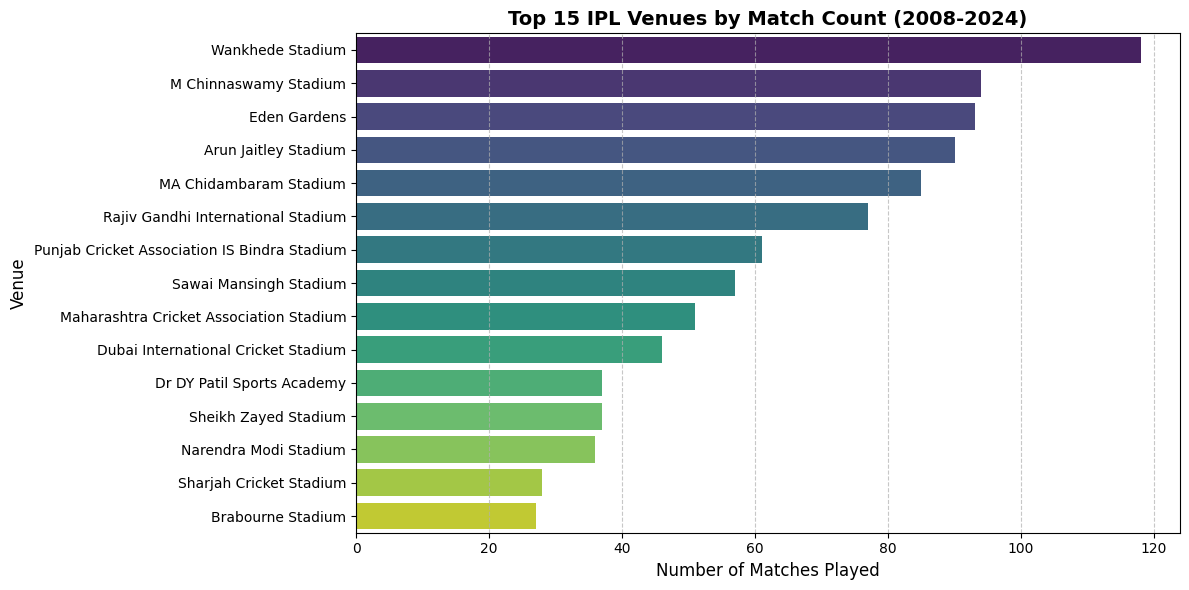

In [33]:
# Venue distribution chart
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate venue match counts
venue_counts = ipl_df['venue'].value_counts().reset_index()
venue_counts.columns = ['Venue', 'Match Count']

# Plotting the top 15 most frequent venues
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Match Count',
    y='Venue',
    data=venue_counts.head(15),
    hue='Venue',
    palette='viridis',
    legend=False
)

plt.title('Top 15 IPL Venues by Match Count (2008-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Matches Played', fontsize=12)
plt.ylabel('Venue', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Matches are concentrated at a handful of grounds. Wankhede Stadium (118) leads, followed by M Chinnaswamy, Eden Gardens, Arun Jaitley and MA Chidambaram, at around 85–95 each. These are long-standing franchise home grounds. Seasons played partly or wholly outside India (2009 in South Africa; 2014, 2020 and part of 2021 in the UAE) added foreign venues with fewer matches.

In [34]:
#In which season Wankhede Hosted most of the matches
ipl_df_wankhede = ipl_df[ipl_df['venue'] == 'Wankhede Stadium']
wankhede_matches_by_season = ipl_df_wankhede.groupby('season')['id'].count().reset_index()
wankhede_matches_by_season.columns = ['Season', 'Matches']
print(wankhede_matches_by_season)

    Season  Matches
0     2008        6
1     2011        9
2     2012        8
3     2013        8
4     2014        6
5     2015        8
6     2016        4
7     2017        8
8     2018        9
9     2019        7
10    2021       10
11    2022       21
12    2023        7
13    2024        7


In [35]:
#As we can see above 2021 and 2022 is where we see Wankhede hosted most matches.
# Let us check for those two seasons what all stadiums were allowed to host IPL
ipl_df_season_2021 = ipl_df[ipl_df['season'] == 2021]
ipl_df_season_2022 = ipl_df[ipl_df['season'] == 2022]
ipl_df_season_2021_venues = ipl_df_season_2021['venue'].unique()
ipl_df_season_2022_venues = ipl_df_season_2022['venue'].unique()
print(f"IPL venues allowed in 2021: {ipl_df_season_2021_venues}")
print(f"IPL venues allowed in 2022: {ipl_df_season_2022_venues}")

IPL venues allowed in 2021: ['MA Chidambaram Stadium' 'Wankhede Stadium' 'Narendra Modi Stadium'
 'Arun Jaitley Stadium' 'Dubai International Cricket Stadium'
 'Sheikh Zayed Stadium' 'Sharjah Cricket Stadium']
IPL venues allowed in 2022: ['Wankhede Stadium' 'Brabourne Stadium' 'Dr DY Patil Sports Academy'
 'Maharashtra Cricket Association Stadium' 'Eden Gardens'
 'Narendra Modi Stadium']


###Observation – COVID-era seasons

In 2021, the India leg was restricted to four venues (MA Chidambaram, Wankhede, Narendra Modi and Arun Jaitley) before the season moved to the UAE. In 2022, the league stage was held at Mumbai and Pune venues to limit travel inside bio-bubbles, with playoffs in Kolkata and Ahmedabad.

Observation – Wankhede

Wankhede's 118 matches come mainly from being Mumbai Indians' home ground across almost every season. 2022 added an unusually high 21 matches, about 18% of its total.

## Toss Factor- Let us check average win percentage by toss winners

In [36]:
# Win Percentage for toss winners

# Overall Toss Win to Match Win conversion rate
overall_toss_win_pct = ipl_df['toss_advantage'].mean() * 100
print(f"Overall Match Win Percentage for Toss Winners: {overall_toss_win_pct:.2f}%")

# Toss Win Percentage by Season
season_toss_win = ipl_df.groupby('season')['toss_advantage'].mean().reset_index()
season_toss_win['toss_advantage'] = season_toss_win['toss_advantage'] * 100
season_toss_win.columns = ['Season', 'Toss Winner Win %']

print("\nSeason-wise Toss Winner Win Percentage:")
display(season_toss_win.style.format({'Toss Winner Win %': '{:.2f}%'}).hide(axis='index'))

# Statistical summary of the season-wise win percentages
print("\nStatistical Summary:")
display(season_toss_win['Toss Winner Win %'].describe())

Overall Match Win Percentage for Toss Winners: 50.83%

Season-wise Toss Winner Win Percentage:


Season,Toss Winner Win %
2008,48.28%
2009,57.89%
2010,51.67%
2011,52.78%
2012,44.59%
2013,47.37%
2014,50.00%
2015,49.12%
2016,56.67%
2017,57.63%



Statistical Summary:


,Toss Winner Win %
count,17.000000
mean,51.131229
std,5.693568
min,41.666667
25%,47.368421
50%,50.000000
75%,56.666667
max,61.016949


### Toss Decision - It seems like winning toss doesn't favour the team, mean is almost 50 and each season wise too, win percentage stayed nearly 45-55, not a deciding factor.
Maybe toss_decision plays some role. Let us check that now

In [37]:
# Win Percentage for toss winners by toss_decision

# Overall Toss Win to Match Win conversion rate by toss decision
toss_win_pct_by_decision = ipl_df.groupby('toss_decision')['toss_advantage'].mean() * 100
print("Overall Match Win Percentage for Toss Winners by Toss Decision:")
for decision, pct in toss_win_pct_by_decision.items():
    print(f"  {decision.capitalize()}: {pct:.2f}%")

# Toss Win Percentage by Season and toss_decision
season_decision_toss_win = ipl_df.groupby(['season', 'toss_decision'])['toss_advantage'].mean().reset_index()
season_decision_toss_win['toss_advantage'] = season_decision_toss_win['toss_advantage'] * 100
season_decision_toss_win.columns = ['Season', 'Toss Decision', 'Toss Winner Win %']

print("\nSeason-wise Toss Winner Win Percentage by Decision:")
display(season_decision_toss_win)

Overall Match Win Percentage for Toss Winners by Toss Decision:
  Bat: 45.38%
  Field: 53.86%

Season-wise Toss Winner Win Percentage by Decision:


,Season,Toss Decision,Toss Winner Win %
0,2008,bat,34.615385
1,2008,field,59.375000
2,2009,bat,54.285714
3,2009,field,63.636364
4,2010,bat,53.846154
5,2010,field,47.619048
6,2011,bat,45.833333
7,2011,field,56.250000
8,2012,bat,40.540541
9,2012,field,48.648649


In [38]:
# Toss winner win % by venue, keeping only venues with enough matches to be meaningful
venue_toss = ipl_df.groupby('venue')['toss_advantage'].agg(['mean', 'count'])
venue_toss['mean'] = venue_toss['mean'] * 100
venue_toss.columns = ['Toss Winner Win %', 'Matches']

venue_toss_filtered = venue_toss[venue_toss['Matches'] >= 20].sort_values('Toss Winner Win %', ascending=False)
display(venue_toss_filtered)

,Toss Winner Win %,Matches
venue,,
Sharjah Cricket Stadium,57.142857,28
Maharashtra Cricket Association Stadium,54.901961,51
Dr DY Patil Sports Academy,54.054054,37
M Chinnaswamy Stadium,53.846154,91
Eden Gardens,52.688172,93
Sawai Mansingh Stadium,52.631579,57
Wankhede Stadium,52.542373,118
Brabourne Stadium,51.851852,27
Sheikh Zayed Stadium,51.351351,37


###Observation - Toss advantage by venue

Keeping venues with at least 20 matches, the toss-winner win % ranges from 36% to 57%. Rajiv Gandhi International Stadium (36%) and Dubai International Cricket Stadium stand out at the low end. Given the number of venues compared, this may partly be chance. These venues are worth examining in the Q6 toss-decision model

In [39]:
from scipy.stats import chi2_contingency

# Does the toss decision affect whether the toss winner wins?
ct = pd.crosstab(ipl_df['toss_decision'], ipl_df['toss_advantage'])
chi2, p, dof, _ = chi2_contingency(ct)
print(ct)
print(f"\nChi-square p-value: {p:.4f}")

toss_advantage  0.0  1.0
toss_decision           
bat             213  177
field           323  377

Chi-square p-value: 0.0088


Observation – Toss decision

Overall, toss winners who chose to field won 53.9% of matches, versus 45.4% for those who chose to bat. The chi-square test (p = 0.0088) shows this difference is statistically significant, so fielding first has been the better choice on average.
Season-level swings, such as 2016, are based on small numbers of bat-first decisions and shouldn't be interpreted individually.

In [40]:
# Final cleanup: drop raw columns replaced by engineered features
ipl_df = ipl_df.drop(columns=['result_margin', 'method'], errors='ignore')

# Remaining NaNs should only be the documented "not applicable" cases
ipl_df.isnull().sum()[ipl_df.isnull().sum() > 0]

,0
player_of_match,5
winner,5
target_runs,3
target_overs,3
result_margin_runs,597
result_margin_wickets,517
toss_advantage,5


## Q1 Summary – Notes & Assumptions

Data quality fixes

Franchise renames merged: Delhi Daredevils → Delhi Capitals, Kings XI Punjab → Punjab Kings, Royal Challengers Bangalore → Bengaluru, and both Rising Pune Supergiant spellings. Deccan Chargers and Sunrisers Hyderabad are kept separate, as are Gujarat Lions and Gujarat Titans (different franchises).
Venue name variants merged, including renames (Feroz Shah Kotla → Arun Jaitley, Subrata Roy Sahara → MCA Stadium, Sardar Patel Stadium, Motera → Narendra Modi Stadium, treated as one venue despite the rebuild).
City standardised: Bangalore → Bengaluru, Navi Mumbai → Mumbai, PCA Stadium → Mohali. The 51 missing cities (UAE matches) were filled from the venue.

Remaining NaNs (by design, meaning "not applicable")

winner, player_of_match, toss_advantage: the 5 no-result matches.
result_margin_runs / result_margin_wickets: one is always NaN, and both are NaN for ties and no-results.
target_runs / target_overs: 3 matches with no play.
No-result rows are kept in the master dataset and filtered per analysis.

Engineered features

is_dl: D/L applied. is_shortened: target overs < 20. Every D/L match is shortened, and 9 further matches were shortened without D/L.
match_importance: league / playoff / final, with all knockout matches grouped as playoff.
season_phase: each season split into equal thirds by match order.
team1_home / team2_home: per the home-advantage observation above.
venue_matches_team1_prior / team2_prior: matches at the venue before the current date, across all seasons.

Leakage warning
winner, result, toss_advantage, both margin columns, player_of_match, target_runs, target_overs, is_dl and is_shortened are known only after or during the match. They must not be used as features for predicting match outcomes. They can be used only in aggregated form from prior matches.

# 2 ) Team Performance Clustering
Cluster teams based on performance-related metrics to identify groups with similar strengths and weaknesses.

### Approach
**Unit of analysis: team-season (146 rows), not team (15 rows).**
- 15 franchises are too few points for K-means, and short-lived teams (Kochi, 14 matches) would sit alongside CSK (230+ matches) with much noisier stats.
- Team-seasons let us see how a franchise moves between performance profiles over time.

The match data is reshaped into long format (one row per team per match, 2,180 rows, no-result matches excluded) so each row describes one team's perspective: did it win, win the toss, play at home.

Clustering is descriptive, not predictive, so outcome columns (winner, margins) are valid inputs here. The leakage rules from Q1 apply only to predictive models.

In [41]:
# Long format: one row per team per match, from that team's perspective
cols = ['id', 'season', 'date', 'venue', 'winner', 'toss_winner',
        'result_margin_runs', 'result_margin_wickets']

team_match = pd.concat([
    ipl_df[cols + ['team1', 'team1_home']].rename(columns={'team1': 'team', 'team1_home': 'is_home'}),
    ipl_df[cols + ['team2', 'team2_home']].rename(columns={'team2': 'team', 'team2_home': 'is_home'}),
], ignore_index=True)

# Drop no-result matches: no winner, so no performance information
team_match = team_match[team_match['winner'].notna()]

# Did this team win the match / win the toss?
team_match['won'] = (team_match['winner'] == team_match['team']).astype(int)
team_match['won_toss'] = (team_match['toss_winner'] == team_match['team']).astype(int)

print(len(team_match))
team_match.head()

2180


,id,season,date,venue,winner,toss_winner,result_margin_runs,result_margin_wickets,team,is_home,won,won_toss
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bengaluru,140.0,NaN,Royal Challengers Bengaluru,1,0,1
1,335983,2008,2008-04-19,Punjab Cricket Association IS Bindra Stadium,Chennai Super Kings,Chennai Super Kings,33.0,NaN,Punjab Kings,1,0,0
2,335984,2008,2008-04-19,Arun Jaitley Stadium,Delhi Capitals,Rajasthan Royals,NaN,9.0,Delhi Capitals,1,1,0
3,335985,2008,2008-04-20,Wankhede Stadium,Royal Challengers Bengaluru,Mumbai Indians,NaN,5.0,Mumbai Indians,1,0,1
4,335986,2008,2008-04-20,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,NaN,5.0,Kolkata Knight Riders,1,1,0


In [42]:
# --- Margins: keep only the team's own wins (NaN elsewhere) ---
team_match['runs_margin_won'] = team_match['result_margin_runs'].where(team_match['won'] == 1)
team_match['wkts_margin_won'] = team_match['result_margin_wickets'].where(team_match['won'] == 1)

keys = ['team', 'season']

# --- Core stats per team-season ---
features = team_match.groupby(keys).agg(
    matches=('won', 'size'),
    win_pct=('won', 'mean'),
    avg_runs_margin=('runs_margin_won', 'mean'),
    avg_wkts_margin=('wkts_margin_won', 'mean'),
)

# --- Toss conversion: win % in matches where the team won the toss ---
features['toss_conversion'] = (team_match[team_match['won_toss'] == 1]
                               .groupby(keys)['won'].mean())

# --- Home edge: home win % minus away win % ---
home_away = team_match.groupby(keys + ['is_home'])['won'].mean().unstack()
features['home_edge'] = home_away[1] - home_away[0]

# --- Venue familiarity edge: win % at the team's all-time top-3 venues minus elsewhere ---
top3 = team_match.groupby('team')['venue'].agg(lambda v: v.value_counts().index[:3].tolist())
team_match['at_top3'] = team_match.apply(lambda r: r['venue'] in top3[r['team']], axis=1).astype(int)
fam = team_match.groupby(keys + ['at_top3'])['won'].mean().unstack()
features['familiarity_edge'] = fam[1] - fam[0]

features.isnull().sum()

,0
matches,0
win_pct,0
avg_runs_margin,8
avg_wkts_margin,2
toss_conversion,0
home_edge,36
familiarity_edge,12


In [43]:
# Edges: no home/top-3 matches means no measurable advantage → 0 (neutral)
features[['home_edge', 'familiarity_edge']] = features[['home_edge', 'familiarity_edge']].fillna(0)

# Margins: no wins of that type that season → 0
features[['avg_runs_margin', 'avg_wkts_margin']] = features[['avg_runs_margin', 'avg_wkts_margin']].fillna(0)

features.isnull().sum()

,0
matches,0
win_pct,0
avg_runs_margin,0
avg_wkts_margin,0
toss_conversion,0
home_edge,0
familiarity_edge,0


### Features (per team-season)
| Feature | Definition |
|---|---|
| win_pct | Share of matches won |
| avg_runs_margin | Average margin in wins by runs (losses excluded) |
| avg_wkts_margin | Average margin in wins by wickets (losses excluded) |
| toss_conversion | Win % in matches where the team won the toss |
| home_edge | Home win % minus away win % |
| familiarity_edge | Win % at the team's all-time top-3 venues minus win % elsewhere |

Home and familiarity are expressed as *edges* (differences) rather than two separate percentages, so each feature directly measures an advantage.

**Missing values filled:**
- `home_edge` (36), `familiarity_edge` (12) → 0. No home or top-3 matches that season (mainly 2009, 2020–2022), so no measurable advantage.
- `avg_runs_margin` (8), `avg_wkts_margin` (2) → 0. No wins of that type that season.

`matches` is kept for reference but excluded from clustering, since it reflects tournament format and playoff runs rather than performance.

### Scaling
K-means groups points by distance, so features on larger scales (runs margins, 0–140) would dominate features on small scales (percentages, 0–1). `StandardScaler` puts every feature on the same scale (mean 0, standard deviation 1). Because clustering is descriptive, the scaler is fitted on all data; there is no train/test split.

In [44]:
cluster_cols = ['win_pct', 'avg_runs_margin', 'avg_wkts_margin',
                'toss_conversion', 'home_edge', 'familiarity_edge']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features[cluster_cols])

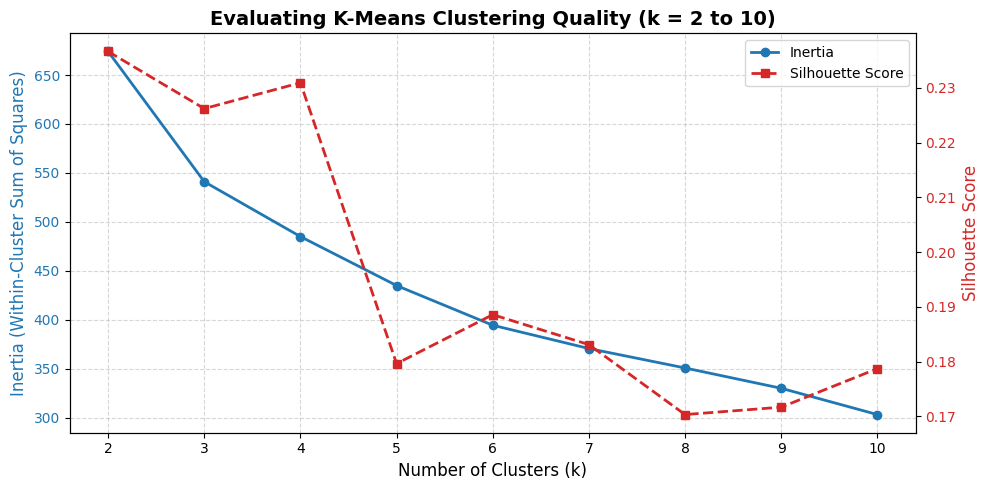

In [45]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Initialize lists to store inertia and silhouette scores
inertia_scores = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    # Use random_state=42 for reproducibility and n_init='10' to avoid warnings
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_scores.append(kmeans.inertia_)

    # Calculate silhouette score
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plotting the results
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Inertia
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', color=color, fontsize=12)
line1 = ax1.plot(k_range, inertia_scores, marker='o', color=color, label='Inertia', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
line2 = ax2.plot(k_range, silhouette_scores, marker='s', color=color, linestyle='--', label='Silhouette Score', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

# Title and legend
plt.title('Evaluating K-Means Clustering Quality (k = 2 to 10)', fontsize=14, fontweight='bold')
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()

In [46]:
for k in [3, 4]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    profile = features[cluster_cols].groupby(km.labels_).mean().round(2)
    profile['n_seasons'] = pd.Series(km.labels_).value_counts().sort_index().values
    print(f"\n--- k = {k} ---")
    display(profile)


--- k = 3 ---


,win_pct,avg_runs_margin,avg_wkts_margin,toss_conversion,home_edge,familiarity_edge,n_seasons
0,0.54,29.78,6.22,0.54,0.35,0.36,40
1,0.55,31.39,6.39,0.58,-0.03,-0.10,74
2,0.30,14.42,5.42,0.25,-0.06,-0.03,32



--- k = 4 ---


,win_pct,avg_runs_margin,avg_wkts_margin,toss_conversion,home_edge,familiarity_edge,n_seasons
0,0.54,29.78,6.22,0.54,0.35,0.36,40
1,0.32,26.81,2.36,0.22,-0.20,-0.20,6
2,0.32,11.77,6.34,0.29,-0.04,0.00,30
3,0.56,32.43,6.32,0.58,-0.03,-0.11,70


### Choosing k = 3
- **Elbow:** the largest drop in inertia is from k = 2 to 3; improvements shrink steadily after k = 4.
- **Silhouette:** k = 2, 3 and 4 score similarly ( ~ 0.23), then drop sharply at k = 5 (~0.18) and never recover.
- **Interpretability:** k = 4 reproduces the k = 3 clusters almost exactly, plus a 6-season cluster split off from the weak group, an outlier split rather than a new team profile. k = 2 would only separate good from bad seasons.

The modest silhouette (~0.23) reflects that team performance varies continuously rather than falling into sharply distinct types. The clusters are useful groupings, not hard categories.

In [47]:
# Final model with k = 3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_scaled)
features['cluster'] = kmeans_final.labels_

# Name clusters from their profiles, not hardcoded numbers
# (cluster numbers can change if the data changes; profiles don't)
profile = features.groupby('cluster')[cluster_cols].mean()
strugglers = profile['win_pct'].idxmin()
fortress = profile.drop(strugglers)['home_edge'].idxmax()
contenders = profile.drop([strugglers, fortress]).index[0]

names = {strugglers: 'Strugglers', fortress: 'Home Fortresses', contenders: 'All-Venue Contenders'}
features['cluster_name'] = features['cluster'].map(names)

# Profile table with readable names
profile.rename(index=names).round(2)

,win_pct,avg_runs_margin,avg_wkts_margin,toss_conversion,home_edge,familiarity_edge
cluster,,,,,,
Home Fortresses,0.54,29.78,6.22,0.54,0.35,0.36
All-Venue Contenders,0.55,31.39,6.39,0.58,-0.03,-0.10
Strugglers,0.30,14.42,5.42,0.25,-0.06,-0.03


### Cluster profiles
| Cluster | Seasons | Win % | Profile |
|---|---|---|---|
| **All-Venue Contenders** | 74 | 55% | Win anywhere, no home dependence (home edge −0.03). Largest runs margins (31.4) and best toss conversion (58%). |
| **Home Fortresses** | 40 | 54% | Same win rate, but driven by home grounds: +35 points better at home, +36 at their top-3 venues. |
| **Strugglers** | 32 | 30% | Narrow wins (14.4 runs on average) and no advantage of any kind. |

**Key insight:** there are two equally successful profiles. Home Fortresses depend on conditions they control; All-Venue Contenders don't. The difference matters most in playoffs, which are often at neutral venues.

*Note:* toss_conversion closely tracks win_pct by construction (it is win % on a subset of matches), so differences in it mostly restate win rate rather than show a separate toss effect.

In [48]:
# Number of seasons each team spent in each cluster
team_cluster = pd.crosstab(features.index.get_level_values('team'), features['cluster_name'])
team_cluster['total'] = team_cluster.sum(axis=1)
team_cluster.sort_values('All-Venue Contenders', ascending=False)

cluster_name,All-Venue Contenders,Home Fortresses,Strugglers,total
row_0,,,,
Mumbai Indians,11,4,2,17
Royal Challengers Bengaluru,9,4,4,17
Kolkata Knight Riders,9,6,2,17
Delhi Capitals,8,4,5,17
Chennai Super Kings,8,6,1,15
Punjab Kings,7,5,5,17
Rajasthan Royals,7,5,3,15
Sunrisers Hyderabad,6,4,2,12
Deccan Chargers,3,0,2,5


### Teams by cluster
- **Mumbai Indians** spent the most seasons as All-Venue Contenders (11 of 17).
- **Chennai Super Kings** is the most consistent franchise: only 1 Struggler season in 15.
- **Kolkata Knight Riders and CSK** have the most Home Fortress seasons (6 each), so a strong home record has been part of their success.
- **Delhi Capitals and Punjab Kings** have the most Struggler seasons (5 of 17 each), so they are the least consistent of the long-running franchises.
- **Royal Challengers Bengaluru** combines 9 contender seasons with 4 struggling ones, so it is high-variance.
- **Pune Warriors** were Strugglers in all 3 of their seasons.

In [49]:
champions = (ipl_df[ipl_df['match_importance'] == 'final'][['season', 'winner']]
             .rename(columns={'winner': 'team'}))

champions.merge(features.reset_index()[['team', 'season', 'cluster_name', 'win_pct']],
                on=['team', 'season'], how='left')

,season,team,cluster_name,win_pct
0,2008,Rajasthan Royals,Home Fortresses,0.812500
1,2009,Deccan Chargers,All-Venue Contenders,0.562500
2,2010,Chennai Super Kings,All-Venue Contenders,0.562500
3,2011,Chennai Super Kings,Home Fortresses,0.687500
4,2012,Kolkata Knight Riders,All-Venue Contenders,0.705882
5,2013,Mumbai Indians,Home Fortresses,0.684211
6,2014,Kolkata Knight Riders,Home Fortresses,0.687500
7,2015,Mumbai Indians,All-Venue Contenders,0.625000
8,2016,Sunrisers Hyderabad,All-Venue Contenders,0.647059
9,2017,Mumbai Indians,All-Venue Contenders,0.705882


### Champions by cluster
- **No champion came from the Strugglers cluster**, and every champion won at least 56% of its matches.
- 11 champions were All-Venue Contenders and 6 were Home Fortresses. **However, this comparison is biased:** in neutral seasons (2009, 2020, 2021) and largely in 2022, no team had home matches, so home_edge was filled with 0 and no team *could* be a Home Fortress. Excluding those 4 seasons, the split is 7 All-Venue vs 6 Home Fortresses, roughly even.
- **Conclusion:** both profiles can win titles. The clear requirement is avoiding a Struggler season, i.e. sustained win rates above ~55%, rather than any one style.

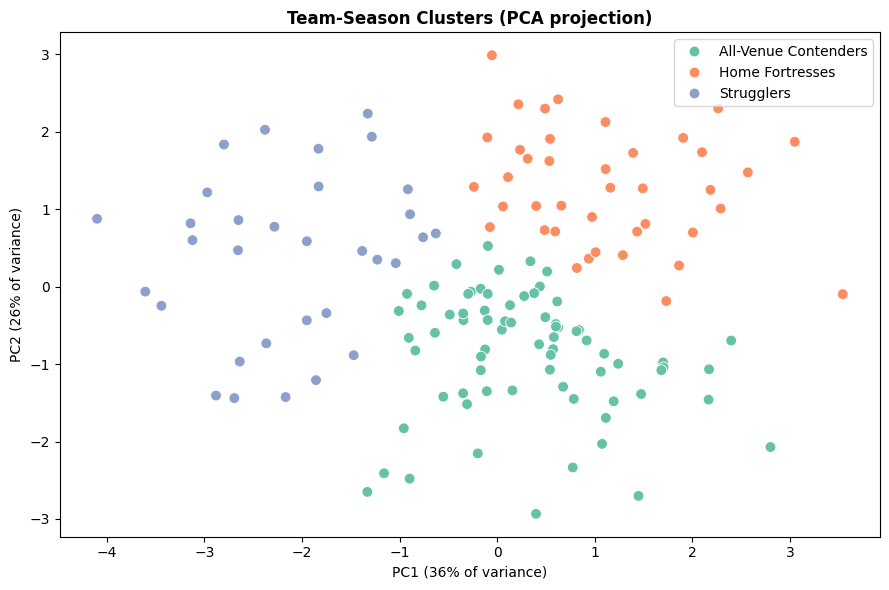

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1],
                hue=features['cluster_name'].values, palette='Set2', s=60)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)')
plt.title('Team-Season Clusters (PCA projection)', fontweight='bold')
plt.tight_layout()
plt.show()

### PCA projection
PCA compresses the six features into two axes for plotting; together they retain **58%** of the variance. The clusters overlap, consistent with the silhouette score of ~0.23: the groups are regions of a continuous spectrum, not isolated islands. The plot is a simplified view; the clustering itself was done on all six features.

### Q2 Summary – Recommendations
1. **Target the All-Venue profile.** Two profiles produce similar win rates, but All-Venue Contenders win with larger margins and don't depend on home conditions, which matters more in neutral-venue playoffs.
2. **For Home Fortress seasons, fix away form.** These teams leave the most on the table on the road; away-match preparation (venue scouting, travel scheduling) is the lever.
3. **Avoid Struggler seasons.** No champion has come from this cluster. For inconsistent franchises (Delhi, Punjab, RCB), consistency is a bigger problem than peak strength.

**Assumptions:** team-season as unit; neutral-season edges filled with 0 (which biases neutral seasons toward All-Venue); k = 3 chosen by elbow, silhouette and interpretability.

# 3 ) Match Outcome Prediction – Logistic Regression

**Goal:** predict the winner of a match using only information available at the time of prediction.

**Design decisions**
- **Prediction moment: at the toss.** The model runs after the toss and before play, so toss winner and toss decision are valid features. This also allows the team × toss interactions the brief asks for.
- **Target:** `team1_won` (1 if team1 wins, else 0). The winner column holds team names, so the match is framed as a yes/no question from team1's point of view. The model's probability for team1 implies 1 − p for team2.
- **No-result matches are excluded**, since they have no winner to learn from.
-

In [51]:
ipl_model = ipl_df[ipl_df['winner'].notna()].copy()
ipl_model['team1_won'] = (ipl_model['winner'] == ipl_model['team1']).astype(int)

print(f"Matches: {len(ipl_model)}")
ipl_model['team1_won'].value_counts(normalize=True)

Matches: 1090


,proportion
team1_won,
1,0.509174
0,0.490826


### Class balance – SMOTE not required
team1 wins 50.9% of matches and loses 49.1%, so the classes are effectively balanced. SMOTE, which creates synthetic minority-class samples, is only needed when one class is rare enough that the model learns to ignore it. Adding synthetic matches here would only add noise.

*Side finding:* team1 is usually the home team, yet wins only 50.9% of matches, so home advantage in the IPL is weak overall, consistent with Q2.

### Form features
Each team's strength going into a match, computed **only from its earlier matches**:
- `form_overall`: win % across all previous matches (long-term strength)
- `form_last5`: win % in the last 5 matches (current momentum)

`shift(1)` moves each team's results down one row, so a match only sees results that happened before it. Without it, a match's own result would be included in its feature, which is leakage. A team's first-ever match has no history and gets a neutral 0.5.

The model also gets **difference features** (team1 form minus team2 form), because what predicts a match is the relative strength of the two teams, not each team's form on its own.

In [52]:
# Long table (one row per team per match) in date order
tm = team_match.sort_values(['date', 'id']).copy()
g = tm.groupby('team')['won']

tm['form_overall'] = g.transform(lambda s: s.shift(1).expanding().mean())
tm['form_last5']   = g.transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
tm[['form_overall', 'form_last5']] = tm[['form_overall', 'form_last5']].fillna(0.5)

# Join back for team1 and team2
form_cols = ['id', 'team', 'form_overall', 'form_last5']
for side in ['team1', 'team2']:
    ipl_model = ipl_model.merge(
        tm[form_cols].rename(columns={'form_overall': f'{side}_form_overall',
                                      'form_last5': f'{side}_form_last5'}),
        left_on=['id', side], right_on=['id', 'team'], how='left'
    ).drop(columns='team')

ipl_model['form_overall_diff'] = ipl_model['team1_form_overall'] - ipl_model['team2_form_overall']
ipl_model['form_last5_diff']   = ipl_model['team1_form_last5']   - ipl_model['team2_form_last5']

print(f"Rows: {len(ipl_model)}")   # should still be 1090
ipl_model[['team1_form_overall', 'team2_form_overall',
           'team1_form_last5', 'team2_form_last5']].isnull().sum()

Rows: 1090


,0
team1_form_overall,0
team2_form_overall,0
team1_form_last5,0
team2_form_last5,0


### Feature set and interactions
| Group | Features | Encoding |
|---|---|---|
| Teams & venue | team1, team2, venue | One-hot |
| Context | match_importance, season_phase, toss_decision | One-hot |
| Toss | toss_winner_is_team1 | 0/1, scaled |
| Home & familiarity | team1_home, team2_home, venue_matches_team1/2_prior | Scaled |
| Form | form_overall, form_last5 (both teams + differences) | Scaled |
| **Interactions** | team × venue, team × toss (for both teams) | One-hot |

**Interactions** capture effects that depend on a combination, e.g. a team that is unusually strong *at one particular venue*. They are built by joining two category values into one string (e.g. "Mumbai Indians | Wankhede Stadium") and one-hot encoding the result.

**Rare combinations:** many team × venue pairs occur only once or twice, and a coefficient learned from two matches is noise. `min_frequency=5` groups combinations seen fewer than 5 times in training into a single "infrequent" category.

In [53]:
# Toss and interaction features
ipl_model['toss_winner_is_team1'] = (ipl_model['toss_winner'] == ipl_model['team1']).astype(int)
ipl_model['team1_x_venue'] = ipl_model['team1'] + ' | ' + ipl_model['venue']
ipl_model['team2_x_venue'] = ipl_model['team2'] + ' | ' + ipl_model['venue']
ipl_model['team1_x_toss']  = ipl_model['team1'] + ' | won_toss=' + ipl_model['toss_winner_is_team1'].astype(str)
ipl_model['team2_x_toss']  = ipl_model['team2'] + ' | won_toss=' + (1 - ipl_model['toss_winner_is_team1']).astype(str)

cat_cols = ['team1', 'team2', 'venue', 'match_importance', 'season_phase', 'toss_decision',
            'team1_x_venue', 'team2_x_venue', 'team1_x_toss', 'team2_x_toss']
num_cols = ['toss_winner_is_team1', 'team1_home', 'team2_home',
            'venue_matches_team1_prior', 'venue_matches_team2_prior',
            'team1_form_overall', 'team2_form_overall', 'team1_form_last5', 'team2_form_last5',
            'form_overall_diff', 'form_last5_diff']

# Time-based split
ipl_model = ipl_model.sort_values(['date', 'id']).reset_index(drop=True)
train = ipl_model[ipl_model['season'] <= 2022]
test  = ipl_model[ipl_model['season'] >= 2023]

X_train, y_train = train[cat_cols + num_cols], train['team1_won']
X_test,  y_test  = test[cat_cols + num_cols],  test['team1_won']
print(f"Train: {len(train)} matches (2008–2022) | Test: {len(test)} matches (2023–2024)")

Train: 946 matches (2008–2022) | Test: 144 matches (2023–2024)


### Train/test split and model setup
**Time-based split:** train on 2008–2022, test on 2023–2024. The franchise will always predict future matches from past ones, so the model is evaluated the same way. A random split would let the model learn from later seasons to predict earlier ones, inflating its score. The test set also includes a realistic difficulty: venues not seen in training (e.g. Mullanpur, first used in 2024).

**Pipeline:** encoding, scaling and the model are combined into one pipeline, so the encoders and scaler are fitted on training data only and never see the test set.

**Regularization (L1 vs L2):** both penalize large coefficients to limit overfitting, important here because the interactions create many sparse columns from about 950 training matches.
- **L2 (ridge)** shrinks all coefficients towards zero.
- **L1 (lasso)** can shrink coefficients *exactly* to zero, which removes features and performs automatic feature selection.

**Tuning:** the regularization strength `C` (smaller = stronger penalty) is chosen by 5-fold `TimeSeriesSplit` cross-validation on the training data, where each fold trains on earlier matches and validates on later ones. The metric is ROC-AUC.

In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import roc_auc_score

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=5), cat_cols),
    ('num', StandardScaler(), num_cols),
])

tscv = TimeSeriesSplit(n_splits=5)
results = {}

for penalty, solver in [('l1', 'liblinear'), ('l2', 'lbfgs')]:
    pipe = Pipeline([
        ('prep', preprocess),
        ('clf', LogisticRegression(penalty=penalty, solver=solver, max_iter=2000)),
    ])
    grid = GridSearchCV(pipe, {'clf__C': [0.001, 0.01, 0.1, 1, 10]},
                        cv=tscv, scoring='roc_auc')
    grid.fit(X_train, y_train)

    proba = grid.predict_proba(X_test)[:, 1]
    results[penalty] = {'model': grid.best_estimator_, 'proba': proba,
                        'best_C': grid.best_params_['clf__C'], 'cv_auc': grid.best_score_,
                        'test_auc': roc_auc_score(y_test, proba)}
    print(f"{penalty.upper()}: best C = {results[penalty]['best_C']}, "
          f"CV AUC = {results[penalty]['cv_auc']:.3f}, Test AUC = {results[penalty]['test_auc']:.3f}")

L1: best C = 1, CV AUC = 0.539, Test AUC = 0.566
L2: best C = 0.001, CV AUC = 0.569, Test AUC = 0.505


### Results – L1 vs L2
| Model | Best C | CV AUC | Test AUC |
|---|---|---|---|
| L1 (lasso) | 1 | 0.541 | **0.566** |
| L2 (ridge) | 0.001 | 0.569 | 0.505 |

- **L2 picked the strongest penalty tested (C = 0.001)**, shrinking nearly all coefficients towards zero. The resulting model predicts close to 50% for every match, and performs at chance on the test set.
- **L1 performs better (0.566)** by setting most sparse interaction features exactly to zero and keeping a small set of informative ones, which suits this data.
- **Caveat:** with 144 test matches, test AUC carries an uncertainty of roughly ±0.05, so the gap is suggestive rather than conclusive.
- **Overall:** AUCs of 0.50–0.57 confirm that T20 outcomes are hard to predict from pre-match information. The model offers a small edge, not a reliable forecast. Much higher scores would have pointed to leakage.

**Selected model: L1-regularized logistic regression.**

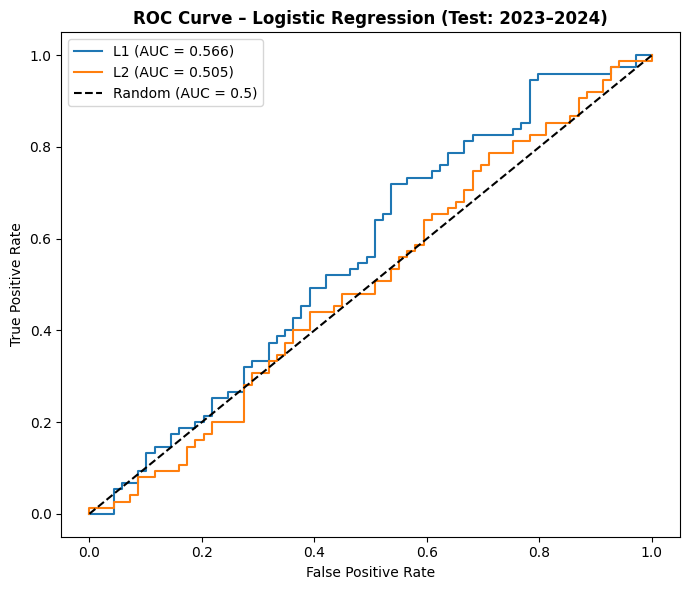

In [55]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))
for penalty in ['l1', 'l2']:
    fpr, tpr, _ = roc_curve(y_test, results[penalty]['proba'])
    plt.plot(fpr, tpr, label=f"{penalty.upper()} (AUC = {results[penalty]['test_auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Logistic Regression (Test: 2023–2024)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

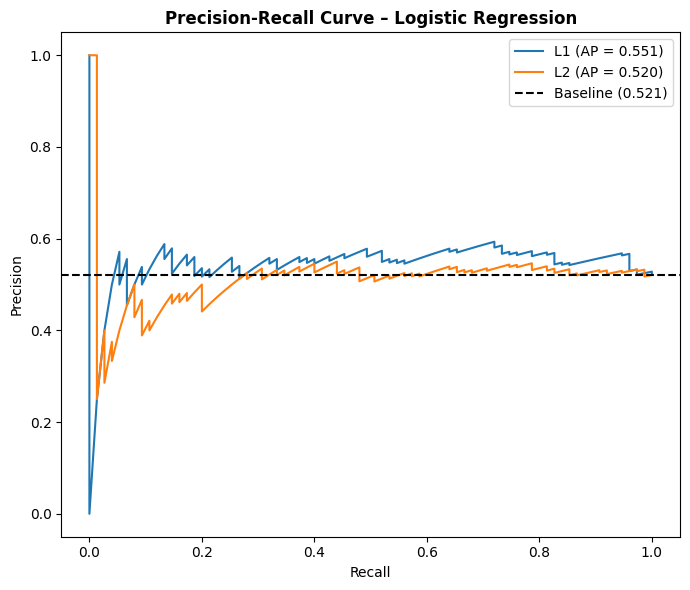

In [56]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7, 6))
for penalty in ['l1', 'l2']:
    prec, rec, _ = precision_recall_curve(y_test, results[penalty]['proba'])
    ap = average_precision_score(y_test, results[penalty]['proba'])
    plt.plot(rec, prec, label=f"{penalty.upper()} (AP = {ap:.3f})")
plt.axhline(y_test.mean(), color='k', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve – Logistic Regression', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Reading the curves
**ROC curve:** plots true positive rate vs false positive rate across all probability thresholds; the diagonal is random guessing.
- L2 tracks the diagonal throughout: its near-constant predictions carry no ranking ability.
- L1 rises above the diagonal mainly in the mid-range (FPR ≈ 0.4–0.8) and stays close to it at low FPR, so its most confident predictions are not much better than chance. Its edge comes from slightly better ranking of ordinary matches.

**Precision-recall curve:** precision = of matches predicted as team1 wins, how many were; recall = of actual team1 wins, how many were caught.
- Baseline = 0.521 (share of team1 wins in 2023–24): always predicting "team1 wins" is right 52.1% of the time.
- **L1 (AP = 0.551)** holds precision around 0.55–0.59 across most of the recall range, a consistent but small improvement of about 3–6 points over the baseline.
- **L2 (AP = 0.520)** sits at or below the baseline.
- The spikes at very low recall come from the first one or two predictions and are not meaningful.

**Practical reading:** when the L1 model favors team1, it is right roughly 55–58% of the time versus 52% by default. That's a modest but real edge, useful as one input among many, not as a standalone forecast.

L1 kept 99 of 251 features (the rest were set to exactly 0)


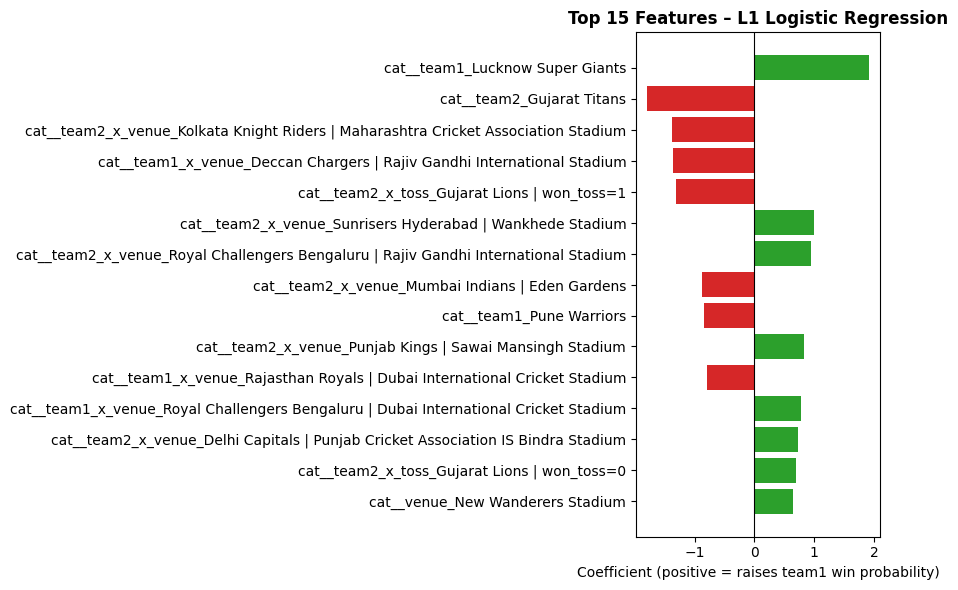

In [57]:
best = results['l1']['model']
feature_names = best.named_steps['prep'].get_feature_names_out()
coefs = pd.Series(best.named_steps['clf'].coef_[0], index=feature_names)

nonzero = coefs[coefs != 0]
print(f"L1 kept {len(nonzero)} of {len(coefs)} features (the rest were set to exactly 0)")

top = nonzero.reindex(nonzero.abs().sort_values(ascending=False).index).head(15)

plt.figure(figsize=(9, 6))
colors = ['tab:green' if c > 0 else 'tab:red' for c in top]
plt.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (positive = raises team1 win probability)')
plt.title('Top 15 Features – L1 Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

In [58]:
# Numeric features: scaled, so their coefficients are directly comparable
num_coefs = coefs[[c for c in coefs.index if c.startswith('num__')]].sort_values()
display(num_coefs.round(3).to_frame('coefficient'))

,coefficient
num__venue_matches_team2_prior,-0.139
num__team2_home,-0.086
num__form_last5_diff,-0.029
num__toss_winner_is_team1,-0.005
num__team1_form_last5,0.000
num__team2_form_overall,0.000
num__team1_home,0.000
num__form_overall_diff,0.034
num__team1_form_overall,0.045
num__venue_matches_team1_prior,0.051


### Numeric feature effects (standardized, directly comparable)
| Feature | Coefficient | Reading |
|---|---|---|
| venue_matches_team2_prior | −0.139 | Opponent's familiarity with the ground lowers team1's chances, the strongest numeric signal |
| team2_form_last5 | +0.133 | Counterintuitive; see below |
| team2_home | −0.086 | Opponent at home lowers team1's chances |
| venue_matches_team1_prior | +0.051 | team1's own ground familiarity helps |
| team1_form_overall / form_overall_diff | +0.045 / +0.034 | Long-term strength helps slightly |
| toss_winner_is_team1 | −0.005 | Toss has essentially no effect (consistent with Q1) |
| team1_home, team1_form_last5, team2_form_overall | 0 | Removed by L1 |

**Key findings:** venue familiarity and home ground are the most consistent signals; the toss contributes nothing.

**Why recent form looks backwards:** `form_last5_diff` is an exact combination of the two team-level form features (**multicollinearity**), so the model splits their effect arbitrarily and individual signs become unreliable. Form over 5 matches is also noisy, and short streaks tend not to last (regression to the mean). **Lesson:** include either the paired features or their difference, not both.

### Q3 Summary
**Model:** L1-regularized logistic regression predicting `team1_won` at toss time, trained on 2008–2022 and tested on 2023–2024 (144 matches). Classes are balanced (50.9 / 49.1), so SMOTE was not needed.

**Performance:** test ROC-AUC 0.566 (L1) vs 0.505 (L2); average precision 0.551 vs a 0.521 baseline. When the model favors team1, it is right about 55–58% of the time versus 52% by default.

**L1 vs L2:** L2 selected the strongest penalty tested and collapsed to near-constant predictions. L1's feature selection (99 of 251 features kept) suited the sparse interaction data better.

**Business takeaways for Cricket Operations:**
1. **Match outcomes are close to unpredictable from pre-match data**; treat model probabilities as a slight tilt, not a forecast.
2. **Venue familiarity matters more than the toss.** Teams that have played more at a ground do better there. Scheduling practice sessions and warm-up matches at upcoming venues is a lever the franchise controls.
3. **Don't overreact to short winning or losing streaks.** Form over 5 matches carries little reliable signal.

**Limitations:** small test set (±0.05 AUC uncertainty); rare one-hot categories received inflated coefficients; defunct teams and neutral venues add noise; the form features are collinear. Possible fixes: higher `min_frequency`, removing defunct teams, and using only difference features.

# 4 ) Performance Trend Analysis

**Goal:** track each team's win % across seasons, fit linear trends to identify improving and declining teams, forecast 2025, and test which factors relate to season performance.

**Approach**
- Unit: team-season (as in Q2). No-result matches are excluded.
- Trend lines are fitted only for teams with **8+ seasons**, since a line through 2–5 points is unreliable. That leaves the 8 long-running franchises.
- Each trend is tested for significance (p < 0.05) rather than labelled improving or declining from the slope's sign alone.

In [59]:
# Season-level win % per team (no-result matches already excluded in team_match)
ts = team_match.groupby(['team', 'season']).agg(
    matches=('won', 'size'),
    win_pct=('won', 'mean'),
).reset_index()

# Wide view: one row per team, one column per season
win_table = ts.pivot(index='team', columns='season', values='win_pct').round(2)
win_table['seasons'] = win_table.notna().sum(axis=1)
win_table.sort_values('seasons', ascending=False)

season,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,seasons
team,,,,,,,,,,,,,,,,,,
Delhi Capitals,0.50,0.67,0.50,0.31,0.61,0.19,0.14,0.38,0.50,0.43,0.36,0.62,0.53,0.62,0.50,0.36,0.50,17
Kolkata Knight Riders,0.46,0.23,0.50,0.53,0.71,0.38,0.69,0.54,0.53,0.56,0.56,0.43,0.50,0.53,0.43,0.43,0.79,17
Mumbai Indians,0.50,0.38,0.69,0.62,0.59,0.68,0.47,0.62,0.50,0.71,0.43,0.69,0.69,0.50,0.29,0.56,0.29,17
Punjab Kings,0.67,0.50,0.29,0.50,0.50,0.50,0.71,0.21,0.29,0.50,0.43,0.43,0.43,0.43,0.50,0.43,0.36,17
Royal Challengers Bengaluru,0.29,0.56,0.50,0.62,0.53,0.56,0.36,0.57,0.56,0.23,0.43,0.38,0.47,0.60,0.56,0.50,0.47,17
Rajasthan Royals,0.81,0.46,0.43,0.46,0.44,0.61,0.50,0.54,NaN,NaN,0.47,0.38,0.43,0.36,0.59,0.50,0.60,15
Chennai Super Kings,0.56,0.57,0.56,0.69,0.56,0.67,0.62,0.59,NaN,NaN,0.69,0.59,0.43,0.69,0.29,0.67,0.50,15
Sunrisers Hyderabad,NaN,NaN,NaN,NaN,NaN,0.59,0.43,0.50,0.65,0.57,0.59,0.40,0.50,0.21,0.43,0.29,0.56,12
Deccan Chargers,0.14,0.56,0.50,0.43,0.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5


### Observation – Yearly win %
- **8 franchises have 12+ seasons** (DC, KKR, MI, PBKS, RCB, RR, CSK, SRH); only these are used for trend lines. The others have 1–5 seasons, too few to fit a meaningful line.
- **CSK and RR have no 2016–17 data** because both franchises were suspended for those two seasons.
- **Performance is highly volatile year to year.** Mumbai Indians swing between 0.29 and 0.71; KKR jumped from 0.43 to 0.79 in 2024. Large swings mean a straight line will explain only a small share of the variation.
- **CSK is the most consistently strong team**, at or above 0.56 in 12 of 15 seasons; its two weak years (2020, 2022) are clear exceptions.
- **Punjab Kings have been at or below 0.50 in every season since 2015.**

In [60]:
from scipy.stats import linregress

rows = []
for team, d in ts.groupby('team'):
    if len(d) < 8:
        continue
    r = linregress(d['season'], d['win_pct'])
    rows.append({
        'team': team, 'seasons': len(d),
        'slope_per_season': r.slope,
        'r2': r.rvalue ** 2,
        'p_value': r.pvalue,
        'pred_2025': np.clip(r.intercept + r.slope * 2025, 0, 1),
    })

trend = pd.DataFrame(rows)
trend['trend'] = np.where(trend['p_value'] < 0.05,
                          np.where(trend['slope_per_season'] > 0, 'Improving', 'Declining'),
                          'No significant trend')
trend.sort_values('slope_per_season', ascending=False).round(3)

,team,seasons,slope_per_season,r2,p_value,pred_2025,trend
2,Kolkata Knight Riders,17,0.006,0.063,0.331,0.575,No significant trend
1,Delhi Capitals,17,0.002,0.005,0.782,0.474,No significant trend
6,Royal Challengers Bengaluru,17,0.001,0.001,0.912,0.488,No significant trend
5,Rajasthan Royals,15,-0.004,0.045,0.450,0.465,No significant trend
0,Chennai Super Kings,15,-0.005,0.066,0.357,0.530,No significant trend
4,Punjab Kings,17,-0.007,0.078,0.276,0.388,No significant trend
3,Mumbai Indians,17,-0.008,0.076,0.283,0.473,No significant trend
7,Sunrisers Hyderabad,12,-0.016,0.201,0.144,0.371,No significant trend


### Observation – Season trends and 2025 forecast
- **No team shows a statistically significant trend** (all p > 0.14). Slopes are small: at most about ±1.6 percentage points per season.
- **The lines explain little of the variation** (R² 0.001–0.20). Year-to-year swings driven by auctions, injuries and form dominate any long-term direction.
- **Directionally:** KKR is the only team leaning upward (+0.6 pts/season). Sunrisers Hyderabad have the steepest decline (−1.6 pts/season, R² 0.20, p = 0.14), followed by Mumbai Indians and Punjab Kings (about −0.7 to −0.8 pts/season). None of these is significant.
- **2025 forecasts cluster between 0.37 and 0.58**, close to the league average. A flat, weak trend line mostly predicts each team's long-run average, so these forecasts add little beyond "about average."
- **Implication:** IPL performance doesn't follow linear long-term trends; it cycles. Season-level factors such as squad changes and recent form are better guides than a team's 17-year trajectory. Punjab Kings' lowest forecast (0.39) is consistent with their long run at or below 0.50.

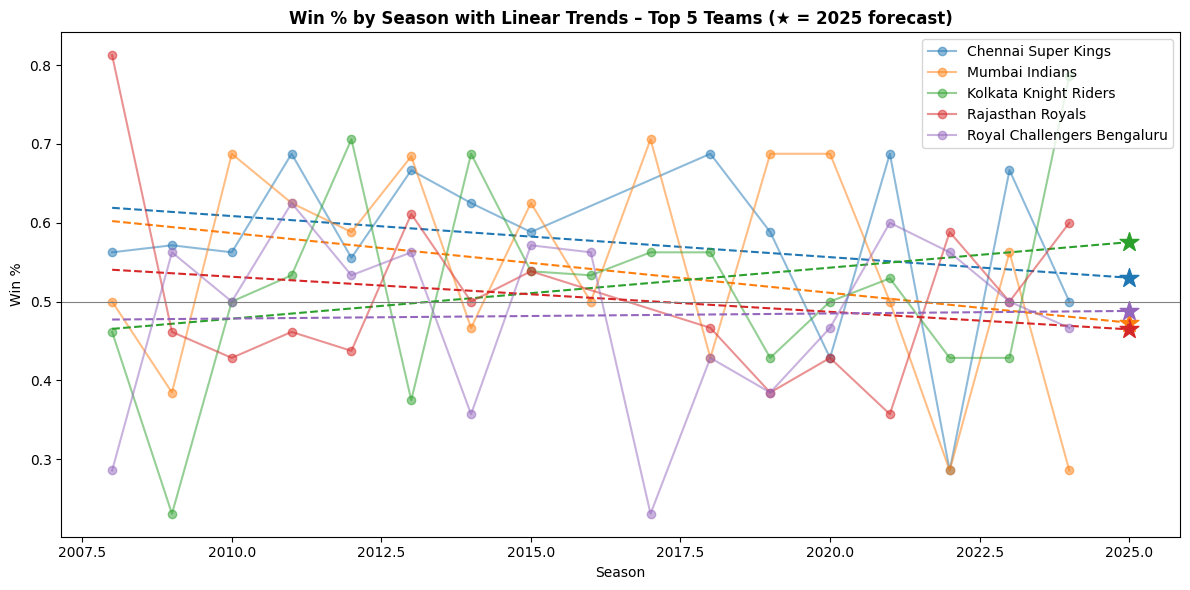

In [61]:
overall = team_match.groupby('team')['won'].mean()
top5 = overall[trend['team']].nlargest(5).index

fig, ax = plt.subplots(figsize=(12, 6))
for team in top5:
    d = ts[ts['team'] == team]
    r = linregress(d['season'], d['win_pct'])
    line = ax.plot(d['season'], d['win_pct'], marker='o', alpha=0.5, label=team)[0]
    years = np.arange(d['season'].min(), 2026)
    ax.plot(years, r.intercept + r.slope * years, linestyle='--', color=line.get_color())
    ax.scatter(2025, np.clip(r.intercept + r.slope * 2025, 0, 1),
               marker='*', s=200, color=line.get_color())

ax.axhline(0.5, color='grey', linewidth=0.8)
ax.set_xlabel('Season')
ax.set_ylabel('Win %')
ax.set_title('Win % by Season with Linear Trends – Top 5 Teams (★ = 2025 forecast)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Observation – Top 5 teams' trends
- Actual win % (solid lines) swings far more than the fitted trends (dashed), confirming the low R² values: a straight line captures very little of how these teams perform.
- **KKR** is the only top team trending upward, with a 2025 forecast of about 0.58, helped by its 0.79 title-winning 2024 season.
- **CSK, Mumbai Indians and Rajasthan Royals** trend gently downward from strong early seasons; Mumbai's forecast (~0.47) is pulled down by two 0.29 seasons in 2022 and 2024.
- **RCB** is almost exactly flat around 0.48, a very consistent average, with no long-term improvement.
- All 2025 forecasts fall between about 0.47 and 0.58, so linear trends predict roughly league-average outcomes for every top team.
- *Note:* CSK's and RR's lines connect across 2016–17, when both teams were suspended; no matches were played in those seasons.

In [62]:
import statsmodels.formula.api as smf

# Opponent for each team-match row
opp = team_match[['id', 'team']].rename(columns={'team': 'opponent'})
tm_opp = team_match.merge(opp, on='id')
tm_opp = tm_opp[tm_opp['team'] != tm_opp['opponent']]

# Opponent strength = opponents' PREVIOUS-season win % (avoids a built-in link with this season)
prev = ts[['team', 'season', 'win_pct']].assign(season=ts['season'] + 1) \
         .rename(columns={'team': 'opponent', 'win_pct': 'opp_prev_win'})
tm_opp = tm_opp.merge(prev, on=['opponent', 'season'], how='left')
tm_opp['opp_prev_win'] = tm_opp['opp_prev_win'].fillna(0.5)

# Season-level factors
factors = tm_opp.groupby(['team', 'season']).agg(
    toss_win_pct=('won_toss', 'mean'),     # pure toss luck
    top3_share=('at_top3', 'mean'),        # venue familiarity exposure
    opp_strength=('opp_prev_win', 'mean'), # opponent strength index
).reset_index()
ts_f = ts.merge(factors, on=['team', 'season'])
ts_f['toss_luck'] = ts_f['toss_win_pct'] - ts_f['win_pct']   # brief's definition, display only

# Standardize so coefficients are comparable, then fit
z = ts_f.copy()
for c in ['toss_win_pct', 'top3_share', 'opp_strength']:
    z[c] = (z[c] - z[c].mean()) / z[c].std()

ols = smf.ols('win_pct ~ toss_win_pct + top3_share + opp_strength', data=z).fit()
print(f"R² = {ols.rsquared:.3f}, n = {int(ols.nobs)}")
ols.summary().tables[1]

R² = 0.011, n = 146


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.4930,0.011,43.597,0.000,0.471,0.515
toss_win_pct,0.0085,0.011,0.751,0.454,-0.014,0.031
top3_share,0.0082,0.011,0.714,0.476,-0.014,0.031
opp_strength,-0.0090,0.011,-0.787,0.433,-0.032,0.014


### Observation – Factors behind season performance
Multiple linear regression of season win % on standardized factors (146 team-seasons):

| Factor | Effect per 1 SD | p-value |
|---|---|---|
| Toss win % (toss luck) | +0.9 pts | 0.45 |
| Top-3 venue share (familiarity) | +0.8 pts | 0.48 |
| Opponent strength (prior-season) | −0.9 pts | 0.43 |

- **The directions make sense**: more tosses won and more games at familiar venues go with slightly higher win %, and tougher opponents with slightly lower. **None of the effects is statistically significant**, and every confidence interval includes zero.
- **R² = 0.011**: the three factors together explain about 1% of the variation in season performance.
- **Contrast with Q3:** venue familiarity was the strongest numeric signal at the match level, but it disappears here. Aggregating to a season averages out match-level effects, and a team's share of top-3 venue matches varies little between seasons.
- **Implication:** season success is driven by factors outside this dataset, such as squad strength, auctions, injuries and player form. Toss luck, venue schedule and fixture difficulty do not explain why one season goes better than another.

**Adjustments to the brief:**
- **Toss luck** was defined in the brief as toss win % − match win %. That contains win % itself, so regressing win % on it would be circular. Toss win % alone (pure luck) is used instead.
- **Opponent strength** uses opponents' *previous-season* win %. Same-season win % is mechanically linked: a strong team lowers its opponents' win % simply by beating them.

### Q4 Summary
1. **No long-running franchise shows a significant long-term trend** (all p > 0.14; R² ≤ 0.20). IPL performance cycles rather than trends.
2. **2025 linear forecasts sit between 0.37 and 0.58**, close to each team's long-run average. KKR (0.58) and CSK (0.53) are highest; Sunrisers Hyderabad (0.37) and Punjab Kings (0.39) lowest.
3. **Toss luck, venue exposure and opponent strength explain about 1% of season-to-season variation.** None is significant.

**For Cricket Operations:** don't plan a season around a team's historical trajectory or fixture difficulty. The drivers of a good season, squad composition and player form, aren't in this dataset. Adding player-level and auction data would be the most valuable next step for season forecasting.

**Limitations:** 12–17 points per team trend line; linear trends can't capture cycles; CSK and RR are missing 2016–17; small and defunct franchises are excluded from trend fitting.

# 5 ) Player of the Match Prediction – KNN

**Goal:** given a match's context, produce a short ranked list of likely Player of the Match (PoM) candidates.

**Key constraint:** the dataset has no squads or player-team information, only the PoM name for each match. Two assumptions follow:
- **A player's team is inferred from their PoM history.** PoM is almost always awarded to a player from the winning team, so a player is linked to the team that won the match where they received the award (their most recent such team at prediction time).
- **Candidates for a match** are players linked to either of the two teams through recent PoM awards. Players who never won a PoM cannot be predicted, which is a known limitation.

**Approach**
1. **Match-context features**, computed from prior matches only: venue chasing bias, venue first-innings scoring rate, shortened-match flag, both teams' recent form, and toss outcome.
2. **KNN on context:** for each match, find the *k* most similar earlier matches involving either team.
3. **Ranking:** candidates score by similarity-weighted PoM wins in those neighbours, combined with their overall prior PoM record. The top 3 names are the prediction.
4. **Evaluation:** top-3 hit rate (is the actual PoM in the top 3?), with *k* tuned by time-based validation.

**Prediction moment:** at the toss, as in Q3.

### Step 1 – Venue context features (prior matches only)
- **Venue chasing bias:** share of earlier matches at the venue won by the chasing team (a win "by wickets" means the chasing side won). Values above 0.5 mean the venue favours chasing.
- **Venue first-innings scoring rate:** average first-innings runs per over in earlier matches at the venue, computed as (target_runs − 1) / target_overs. Using runs *per over* keeps shortened matches comparable with full 20-over matches.

Both use `shift(1)` within each venue, so a match never sees its own result. A venue's first match has no history and gets a neutral or league-level value.

In [63]:
# Base: matches with a result (from Q3), which already have form and toss features
pom_df = ipl_model.sort_values(['date', 'id']).reset_index(drop=True).copy()

# Per-match raw values (outcomes, used only as history for later matches)
pom_df['chase_won'] = np.where(pom_df['result'] == 'wickets', 1,
                       np.where(pom_df['result'] == 'runs', 0, np.nan))   # ties → NaN
pom_df['first_inn_rpo'] = (pom_df['target_runs'] - 1) / pom_df['target_overs']

# Prior-only venue features
gv = pom_df.groupby('venue')
pom_df['venue_chase_bias'] = gv['chase_won'].transform(lambda s: s.shift(1).expanding().mean())
pom_df['venue_first_inn_rpo'] = gv['first_inn_rpo'].transform(lambda s: s.shift(1).expanding().mean())

# A venue's first match: neutral chase bias; league-average scoring rate up to that date
league_rpo_prior = pom_df['first_inn_rpo'].shift(1).expanding().mean()
pom_df['venue_chase_bias'] = pom_df['venue_chase_bias'].fillna(0.5)
pom_df['venue_first_inn_rpo'] = pom_df['venue_first_inn_rpo'].fillna(league_rpo_prior).fillna(8.0)  # 8.0 only for the very first match

print(len(pom_df))
pom_df[['venue_chase_bias', 'venue_first_inn_rpo']].describe().round(3)

1090


,venue_chase_bias,venue_first_inn_rpo
count,1090.000,1090.000
mean,0.534,8.146
std,0.151,0.557
min,0.000,5.500
25%,0.471,7.850
50%,0.536,8.156
75%,0.592,8.384
max,1.000,12.000


### Observation – Venue features
- **Average venue chasing bias is 0.534**: across venues, chasing teams have won slightly more often, consistent with Q1's finding that fielding first is the better toss choice.
- **First-innings scoring averages 8.15 runs per over** (middle 50% of venues: 7.85–8.38).
- **The extremes** (chase bias 0 or 1; 5.5 or 12 runs per over) come from venues with only one or two prior matches and are small-sample noise. *Limitation:* shrinking new venues' values toward the league average would reduce this.

### Step 2 – Candidate players and coverage
For each match, the candidate list contains players whose **most recent PoM award (before this match, within the current and previous two seasons)** was won with team1 or team2. The 3-season window reflects auctions and transfers: a player's team from five years ago is unreliable.

**Coverage** is the share of matches where the actual PoM is in the candidate list. It sets the **ceiling** for any model: if the right player isn't a candidate, he can't be predicted.

In [64]:
# Each PoM award, linked to the winning team (assumption: PoM comes from the winning side)
pom_records = pom_df[['date', 'season', 'player_of_match', 'winner']] \
    .rename(columns={'player_of_match': 'player', 'winner': 'team'})

def get_candidates(match, records, lookback=3):
    prior = records[(records['date'] < match['date']) &
                    (records['season'] > match['season'] - lookback)]
    latest_team = prior.sort_values('date').groupby('player')['team'].last()
    return latest_team[latest_team.isin([match['team1'], match['team2']])].index.tolist()

pom_df['candidates'] = [get_candidates(r, pom_records) for _, r in pom_df.iterrows()]
pom_df['n_candidates'] = pom_df['candidates'].str.len()
pom_df['pom_covered'] = [p in c for p, c in zip(pom_df['player_of_match'], pom_df['candidates'])]

test_mask = pom_df['season'] >= 2023
print(f"Coverage – all matches: {pom_df['pom_covered'].mean():.1%}, test (2023–24): {pom_df.loc[test_mask, 'pom_covered'].mean():.1%}")
print(f"Average candidates per match: {pom_df['n_candidates'].mean():.1f}")
print(f"Random top-3 hit rate (test): {(3 / pom_df.loc[test_mask, 'n_candidates'].clip(lower=3)).mean():.1%}")

Coverage – all matches: 56.4%, test (2023–24): 65.3%
Average candidates per match: 17.4
Random top-3 hit rate (test): 15.4%


### Observation – Candidates and coverage
- On average a match has **17.4 candidates**, players linked to either team through PoM awards in the last three seasons.
- **Coverage is 56.4% overall and 65.3% for the 2023–24 test seasons.** In the remaining matches the PoM was a first-time winner or had recently changed teams, so no model based on this data can predict them. **65% is therefore the ceiling for test accuracy.**
- Coverage is lower overall because early seasons have little PoM history to draw on.

### Step 3 – KNN scoring and tuning k
**Context features** (standardized; the scaler is fitted on 2008–2022 only): venue chasing bias, venue first-innings scoring rate, shortened-match flag, both teams' last-5 form, toss winner, toss decision.

**For each match:**
1. Take all *earlier* matches involving either team, and find the *k* nearest by distance in context space.
2. Each neighbour "votes" for its PoM, weighted by similarity (1 / (1 + distance)). Votes only count for this match's candidates.
3. Add a small prior: 0.1 × the candidate's PoM awards in the last three seasons. This breaks ties and rewards consistent match-winners.
4. The top 3 scores are the prediction.

**Tuning:** *k* is chosen by top-3 hit rate on **2019–2022** (validation), then evaluated once on 2023–2024 (test). **k = 0 means prior only**: it ranks candidates purely by recent PoM count, a strong simple baseline that KNN must beat.

In [65]:
from sklearn.preprocessing import StandardScaler

pom_df['toss_field'] = (pom_df['toss_decision'] == 'field').astype(int)
ctx_cols = ['venue_chase_bias', 'venue_first_inn_rpo', 'is_shortened',
            'team1_form_last5', 'team2_form_last5', 'toss_winner_is_team1', 'toss_field']

scaler = StandardScaler().fit(pom_df.loc[pom_df['season'] <= 2022, ctx_cols])
X_ctx = scaler.transform(pom_df[ctx_cols])

def predict_top3(i, k, lam=0.1):
    m = pom_df.iloc[i]
    cands = m['candidates']
    if not cands:
        return []
    scores = pd.Series(0.0, index=cands)

    # KNN votes from similar earlier matches involving either team
    if k > 0:
        prev = pom_df.iloc[:i]
        teams = [m['team1'], m['team2']]
        idx = prev.index[(prev['date'] < m['date']) &
                         (prev['team1'].isin(teams) | prev['team2'].isin(teams))].to_numpy()
        if len(idx):
            d = np.linalg.norm(X_ctx[idx] - X_ctx[i], axis=1)
            order = np.argsort(d)[:k]
            for j, dist in zip(idx[order], d[order]):
                p = pom_df.at[j, 'player_of_match']
                if p in scores.index:
                    scores[p] += 1 / (1 + dist)

    # Prior: recent PoM count
    recent = pom_records[(pom_records['date'] < m['date']) & (pom_records['season'] > m['season'] - 3)]
    scores += lam * recent['player'].value_counts().reindex(cands).fillna(0)
    return scores.sort_values(ascending=False).head(3).index.tolist()

def hit_rate(mask, k):
    idxs = np.where(mask)[0]
    return np.mean([pom_df.at[i, 'player_of_match'] in predict_top3(i, k) for i in idxs])

val_mask = pom_df['season'].between(2019, 2022)
test_mask = pom_df['season'] >= 2023

for k in [0, 5, 10, 20, 40, 80]:
    print(f"k = {k:>2}: validation top-3 hit rate = {hit_rate(val_mask, k):.1%}")

rand = (pom_df.loc[test_mask, 'pom_covered'] *
        (3 / pom_df.loc[test_mask, 'n_candidates'].clip(lower=3))).mean()
print(f"\nRandom baseline (test, uncovered matches counted as misses): {rand:.1%}")

k =  0: validation top-3 hit rate = 17.0%
k =  5: validation top-3 hit rate = 16.2%
k = 10: validation top-3 hit rate = 17.0%
k = 20: validation top-3 hit rate = 17.8%
k = 40: validation top-3 hit rate = 19.0%
k = 80: validation top-3 hit rate = 19.4%

Random baseline (test, uncovered matches counted as misses): 10.0%


In [66]:
# Extend the grid past the boundary
val_scores = {k: hit_rate(val_mask, k) for k in [80, 120, 160, 250]}
for k, s in val_scores.items():
    print(f"k = {k:>3}: validation top-3 hit rate = {s:.1%}")

best_k = max({**{80: val_scores[80]}, **val_scores}, key=val_scores.get)
print(f"\nChosen k = {best_k}")

# One-time test evaluation: chosen k vs prior-only baseline
print(f"Test top-3 hit rate – KNN (k = {best_k}): {hit_rate(test_mask, best_k):.1%}")
print(f"Test top-3 hit rate – prior only (k = 0): {hit_rate(test_mask, 0):.1%}")
print(f"Coverage ceiling (test): {pom_df.loc[test_mask, 'pom_covered'].mean():.1%}  |  Random: {rand:.1%}")

k =  80: validation top-3 hit rate = 19.4%
k = 120: validation top-3 hit rate = 16.2%
k = 160: validation top-3 hit rate = 17.4%
k = 250: validation top-3 hit rate = 16.6%

Chosen k = 80
Test top-3 hit rate – KNN (k = 80): 18.1%
Test top-3 hit rate – prior only (k = 0): 20.8%
Coverage ceiling (test): 65.3%  |  Random: 10.0%


### Observation – Tuning and test results
| Method | Validation (2019–22) | Test (2023–24) |
|---|---|---|
| Random (3 of the candidates) | – | 10.0% |
| Prior only (k = 0): rank by recent PoM count | 17.0% | **20.8%** |
| KNN + prior (k = 80) | **19.4%** | 18.1% |
| Coverage ceiling | – | 65.3% |

- **k = 80 was best on validation**; larger values (120–250) scored lower, so the tuning peak is genuine rather than a grid boundary.
- **On the test set, the prior-only ranking beat KNN** (20.8% vs 18.1%). With 144 test matches (±3 points uncertainty), neither is reliably better.
- **Interpretation:** the best predictor of Player of the Match is *who has been winning it recently* for these teams. Venue conditions, form and toss context

In [67]:
i = pom_df.index[test_mask][-1]          # last test match (2024 final)
m = pom_df.iloc[i]
print(f"{m['date'].date()} – {m['team1']} vs {m['team2']} at {m['venue']}")
print(f"Predicted top 3 (prior only): {predict_top3(i, 0)}")
print(f"Predicted top 3 (KNN, k=80):  {predict_top3(i, 80)}")
print(f"Actual PoM: {m['player_of_match']}")

2024-05-26 – Sunrisers Hyderabad vs Kolkata Knight Riders at MA Chidambaram Stadium
Predicted top 3 (prior only): ['AD Russell', 'Abhishek Sharma', 'CV Varun']
Predicted top 3 (KNN, k=80):  ['RK Singh', 'S Dhawan', 'AD Russell']
Actual PoM: MA Starc


### Example – 2024 final (KKR vs SRH)
- Prior-only top 3: Russell, Abhishek Sharma, Varun Chakravarthy. KNN top 3: Rinku Singh, Dhawan, Russell. **Actual: Mitchell Starc.**
- Starc returned to the IPL with KKR in 2024 after several seasons away, so he had little recent PoM history: an example of the coverage limitation.
- Dhawan (Punjab Kings in 2022–24) appearing as a candidate shows the risk of the "PoM comes from the winning team" assumption: a single award won in a losing cause links a player to the wrong team.
- Both errors point to the same fix: real squad data would make the candidate lists accurate.

### Q5 Summary
**Method:** KNN over match context (venue chasing bias, venue scoring rate, shortened-match flag, team form, toss), with candidate players inferred from recent PoM awards. k was tuned on 2019–2022 with time-based validation and tested once on 2023–2024.

**Results:** top-3 hit rate 18–21% on the test set, about double random guessing (10%), against a 65% ceiling set by candidate coverage. A simple ranking by recent PoM count performed as well as KNN.

**Takeaways for Cricket Operations:**
1. **Match-winners are repeat performers.** Recent PoM history is the single best indicator of who will decide the next match, so it's useful when weighing retention and auction priorities.
2. **Context-based prediction adds little** with match-level data alone; per-player batting and bowling data would be needed for a meaningfully better model.

**Assumptions & limitations:**
- Player-team links are inferred from PoM awards (assumed to come from the winning team); there is no squad data.
- Players without a prior PoM award cannot be predicted (35% of test matches).
- Context features are oriented by team1/team2 slot, so a team's form appears in different columns across neighbours.
- Venues with few prior matches have noisy chase-bias and scoring-rate values.

# 6 ) Toss Decision Strategy – Decision Tree

**Goal:** recommend whether the toss winner should bat or field first, as readable rules for captains.

**Approach:** model the probability that the **toss winner wins the match**, with the toss decision as one of the features. For any match context, compare the predicted win probability for *bat* and for *field*, and recommend the higher. The decision tree's splits translate directly into if-then rules.

**Features** (toss winner's perspective; all known at the toss):
- **Venue history:** venue chasing bias, venue first-innings scoring rate (from Q5, prior matches only)
- **Team strengths:** toss winner's and opponent's last-5 form
- **Match importance:** league / playoff / final
- **Weather (synthetic):** humidity and rain probability. The dataset has no weather data, so these are generated randomly, **independent of match outcomes**. They stand in for real weather data in a production model; any split the tree makes on them is noise.
- **Toss decision:** field (1) or bat (0)

**Split:** train on 2008–2022, test on 2023–2024, as in Q3.

In [68]:
tdf = pom_df.copy()

# Toss winner's perspective
tw1 = tdf['toss_winner_is_team1'] == 1
tdf['tw_form_last5']  = np.where(tw1, tdf['team1_form_last5'], tdf['team2_form_last5'])
tdf['opp_form_last5'] = np.where(tw1, tdf['team2_form_last5'], tdf['team1_form_last5'])
tdf['match_importance_code'] = tdf['match_importance'].map({'league': 0, 'playoff': 1, 'final': 2})

# Synthetic weather: random, seeded for reproducibility, independent of outcomes
rng = np.random.default_rng(42)
tdf['humidity']  = rng.normal(65, 10, len(tdf)).clip(30, 95).round(0)
tdf['rain_prob'] = rng.beta(2, 8, len(tdf)).round(2)

# Target: did the toss winner win?
tdf['toss_winner_won'] = tdf['toss_advantage'].astype(int)

tree_cols = ['toss_field', 'venue_chase_bias', 'venue_first_inn_rpo', 'tw_form_last5',
             'opp_form_last5', 'match_importance_code', 'humidity', 'rain_prob']

print(len(tdf))
tdf.groupby('toss_field')['toss_winner_won'].agg(['mean', 'count']).round(3)

1090


,mean,count
toss_field,,
0,0.454,390
1,0.539,700


### Step 2 – Training the tree
- **max_depth = 5**, as the brief requires, keeps the rules readable.
- **min_samples_leaf** is tuned with time-based cross-validation (TimeSeriesSplit on 2008–2022). It sets the minimum number of matches in a leaf, which stops the tree from making rules out of a handful of games, the same small-sample problem we've met throughout.
- Decision trees need **no scaling**: they split on thresholds of one feature at a time, so feature units don't matter.

In [69]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import roc_auc_score

tdf = tdf.sort_values(['date', 'id']).reset_index(drop=True)
t_train = tdf[tdf['season'] <= 2022]
t_test  = tdf[tdf['season'] >= 2023]

grid = GridSearchCV(
    DecisionTreeClassifier(max_depth=5, random_state=42),
    {'min_samples_leaf': [20, 40, 60, 80, 120]},
    cv=TimeSeriesSplit(n_splits=5), scoring='roc_auc')
grid.fit(t_train[tree_cols], t_train['toss_winner_won'])

tree = grid.best_estimator_
test_auc = roc_auc_score(t_test['toss_winner_won'], tree.predict_proba(t_test[tree_cols])[:, 1])
print(f"Best min_samples_leaf = {grid.best_params_['min_samples_leaf']}, "
      f"CV AUC = {grid.best_score_:.3f}, Test AUC = {test_auc:.3f}")

pd.Series(tree.feature_importances_, index=tree_cols).sort_values(ascending=False).round(3)

Best min_samples_leaf = 60, CV AUC = 0.525, Test AUC = 0.540


,0
humidity,0.292
venue_chase_bias,0.226
venue_first_inn_rpo,0.208
toss_field,0.198
rain_prob,0.076
tw_form_last5,0.000
match_importance_code,0.000
opp_form_last5,0.000


### Observation – Tree with synthetic weather
- Best min_samples_leaf = 60; CV AUC 0.525, test AUC 0.540, a weak but above-chance signal.
- **The randomly generated humidity is the top feature (0.29), and the synthetic weather features together take 37% of importance**, despite containing no information about outcomes by construction.
- **Lesson:** decision trees choose the best split in the training data, so with enough candidate thresholds a random feature will appear useful by chance. Impurity-based importance also favours continuous features, which offer many split points. Importance scores show what the tree used, not what is truly predictive.
- **Real signals:** venue chasing bias, venue scoring rate and toss decision. Team form and match importance were never used.
- **Decision:** the synthetic weather is removed for the final model, since rules built on random data would mislead captains. With real weather data (dew, humidity), this feature group would be worth revisiting, because dew is widely believed to favour chasing in evening matches.

In [70]:
tree_cols_final = ['toss_field', 'venue_chase_bias', 'venue_first_inn_rpo',
                   'tw_form_last5', 'opp_form_last5', 'match_importance_code']

grid_f = GridSearchCV(
    DecisionTreeClassifier(max_depth=5, random_state=42),
    {'min_samples_leaf': [20, 40, 60, 80, 120]},
    cv=TimeSeriesSplit(n_splits=5), scoring='roc_auc')
grid_f.fit(t_train[tree_cols_final], t_train['toss_winner_won'])

tree_f = grid_f.best_estimator_
test_auc_f = roc_auc_score(t_test['toss_winner_won'],
                           tree_f.predict_proba(t_test[tree_cols_final])[:, 1])
print(f"Best min_samples_leaf = {grid_f.best_params_['min_samples_leaf']}, "
      f"CV AUC = {grid_f.best_score_:.3f}, Test AUC = {test_auc_f:.3f}")

pd.Series(tree_f.feature_importances_, index=tree_cols_final).sort_values(ascending=False).round(3)

Best min_samples_leaf = 60, CV AUC = 0.539, Test AUC = 0.465


,0
venue_first_inn_rpo,0.388
venue_chase_bias,0.380
toss_field,0.232
tw_form_last5,0.000
opp_form_last5,0.000
match_importance_code,0.000


### Observation – Final tree (without synthetic weather)
- Removing the synthetic weather **raised CV AUC from 0.525 to 0.539**, and importance now rests entirely on real features: venue scoring rate (0.39), venue chasing bias (0.38) and toss decision (0.23). Team form and match importance were never used.
- **Test AUC fell to 0.465**, around chance level (±0.05 with 144 matches). Venue patterns learned on 2008–2022 did not transfer to 2023–24.
- **Likely cause: distribution shift.** The **Impact Player rule (introduced in 2023)** added batting depth and pushed scoring rates sharply higher in 2023–24. Thresholds on venue scoring rate learned in a lower-scoring era no longer mean the same thing.
- The earlier test AUC of 0.540 with weather included was chance, not a benefit of the random features.
- **Implication:** the tree's rules describe *historical* tendencies and should be retrained on post-2023 seasons before being trusted for current decisions.

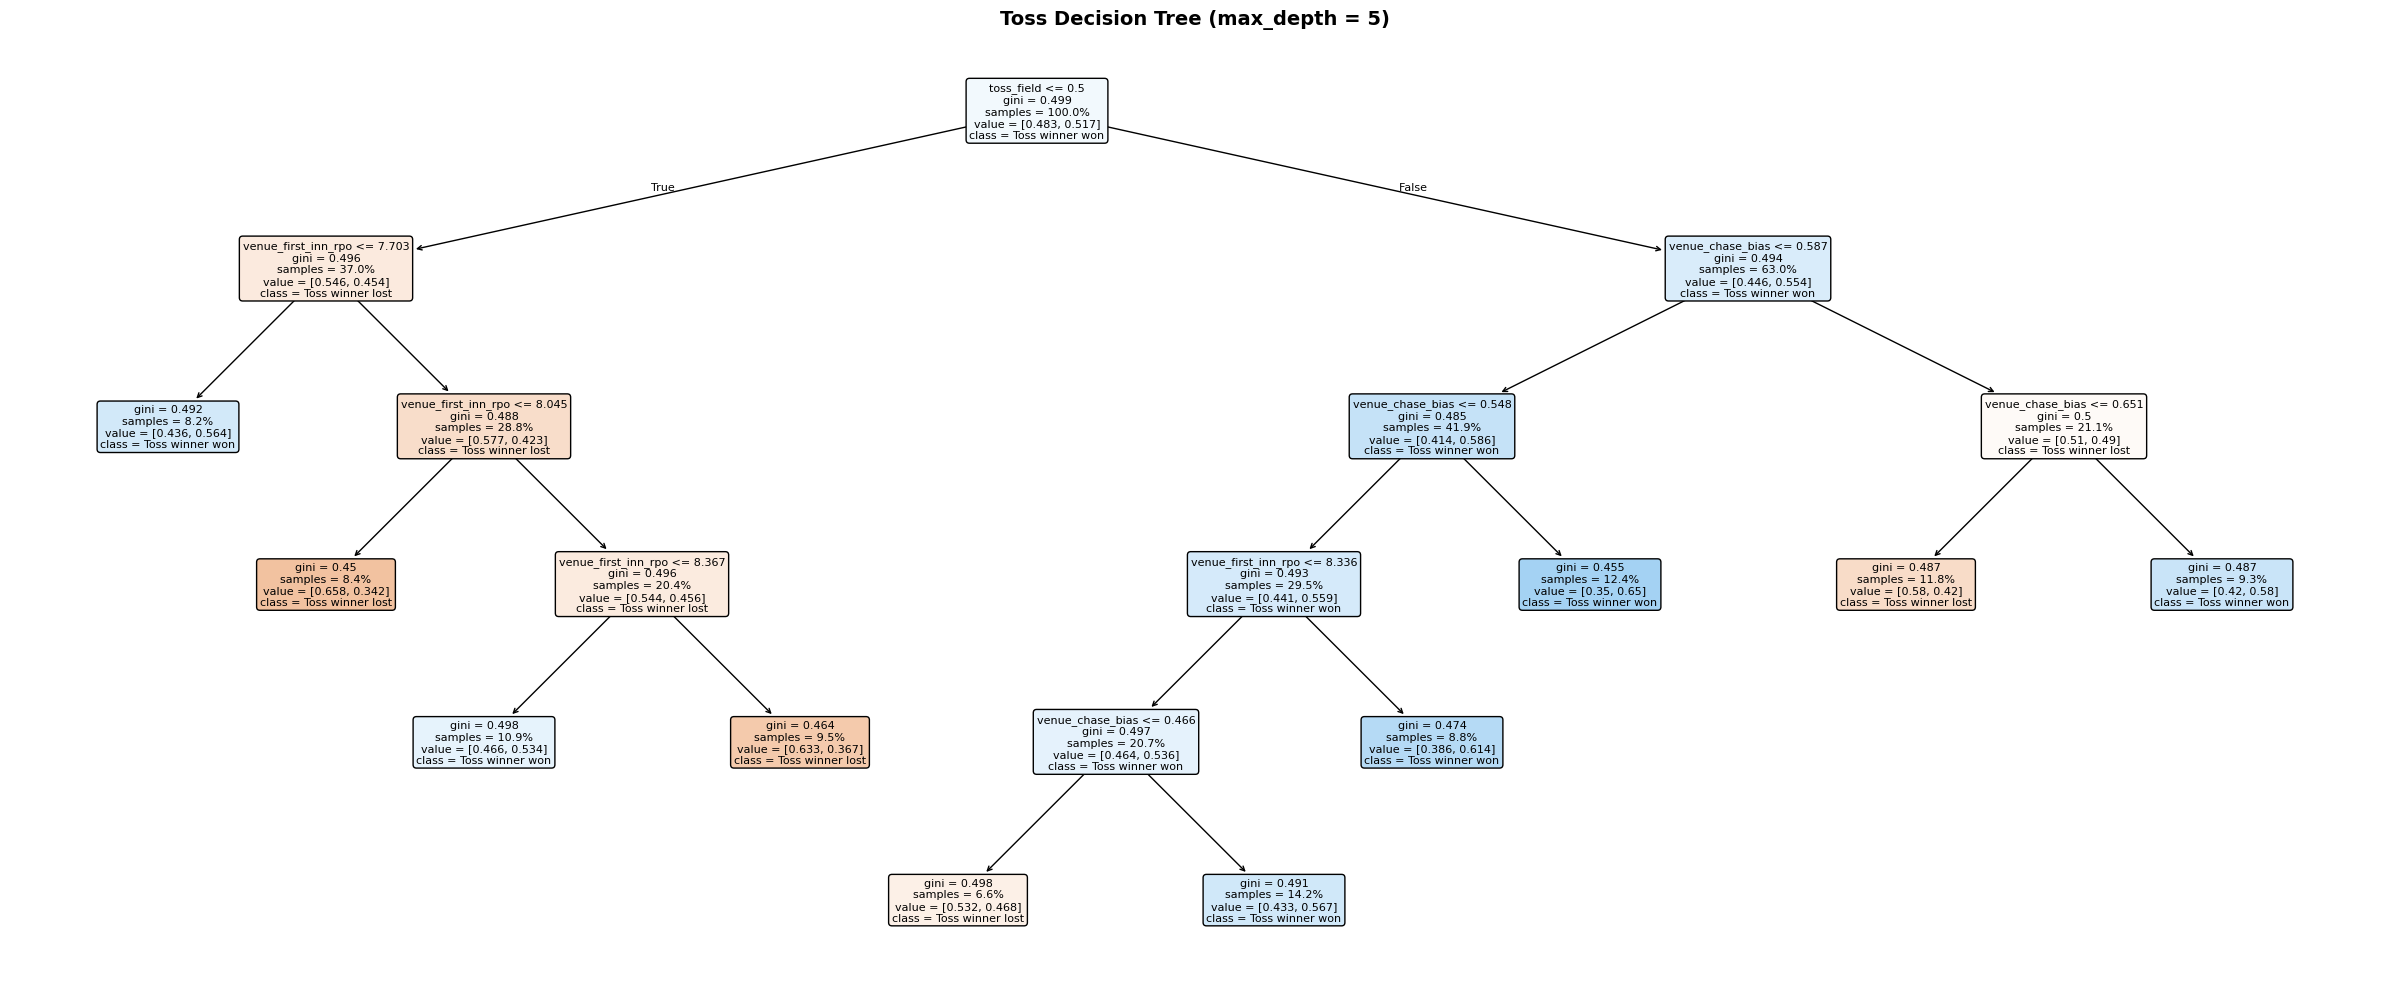

|--- toss_field <= 0.50
|   |--- venue_first_inn_rpo <= 7.70
|   |   |--- weights: [34.00, 44.00] class: 1
|   |--- venue_first_inn_rpo >  7.70
|   |   |--- venue_first_inn_rpo <= 8.05
|   |   |   |--- weights: [52.00, 27.00] class: 0
|   |   |--- venue_first_inn_rpo >  8.05
|   |   |   |--- venue_first_inn_rpo <= 8.37
|   |   |   |   |--- weights: [48.00, 55.00] class: 1
|   |   |   |--- venue_first_inn_rpo >  8.37
|   |   |   |   |--- weights: [57.00, 33.00] class: 0
|--- toss_field >  0.50
|   |--- venue_chase_bias <= 0.59
|   |   |--- venue_chase_bias <= 0.55
|   |   |   |--- venue_first_inn_rpo <= 8.34
|   |   |   |   |--- venue_chase_bias <= 0.47
|   |   |   |   |   |--- weights: [33.00, 29.00] class: 0
|   |   |   |   |--- venue_chase_bias >  0.47
|   |   |   |   |   |--- weights: [58.00, 76.00] class: 1
|   |   |   |--- venue_first_inn_rpo >  8.34
|   |   |   |   |--- weights: [32.00, 51.00] class: 1
|   |   |--- venue_chase_bias >  0.55
|   |   |   |--- weights: [41.00, 76.00]

In [71]:
from sklearn.tree import plot_tree, export_text

plt.figure(figsize=(24, 10))
plot_tree(tree_f, feature_names=tree_cols_final, class_names=['Toss winner lost', 'Toss winner won'],
          filled=True, rounded=True, proportion=True, fontsize=8)
plt.title('Toss Decision Tree (max_depth = 5)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print(export_text(tree_f, feature_names=tree_cols_final, show_weights=True))

### Decision rules in plain English
**Batting first** (toss winner won 45% overall):
- At **low-scoring venues** (first-innings rate ≤ 7.7 runs/over): won **56%** (78 matches).
- At **high-scoring venues** (> 8.37 runs/over): won only **37%** (90 matches).
- In between, results alternate (34% and 53%), with no consistent pattern.

**Fielding first** (toss winner won 54% overall):
- At venues with **moderate chasing bias (0.47–0.59)**: won **57–65%** (251 matches), the strongest and largest group.
- At **high-scoring venues** with chase bias ≤ 0.55: won **61%** (83 matches).
- At venues with chase bias ≤ 0.47 (defending historically easier): won only **47%** (62 matches).

**Caution:** several adjacent leaves alternate sharply (e.g. batting: 56% → 34% → 53% → 37% as scoring rises; fielding: a 42% dip between 65% and 58%). There's no cricket logic for this, so these splits likely reflect noise, consistent with the near-chance test AUC.

### Recommendations for captains
1. **Default to fielding first.** It is the better choice in most venue conditions, and the overall gap (54% vs 45%) is statistically significant (Q1 chi-square, p = 0.009).
2. **Consider batting first only at low-scoring, bowling-friendly venues** (historical first-innings rate ≤ 7.7 runs per over), the one context where batting first matched or beat the average.
3. **Avoid batting first at high-scoring venues.** Toss winners who batted there won only 37% of the time.
4. **Treat venue-specific thresholds as guidance, not rules.** The tree's test AUC (0.465) shows that these patterns did not hold in 2023–24, most likely because the Impact Player rule raised scoring. Retrain on post-2023 matches before relying on exact thresholds.

### Q6 Summary
- **Model:** decision tree (max_depth 5, min_samples_leaf 60, tuned by time-based CV), predicting whether the toss winner wins, with the toss decision as a feature.
- **Feature importance:** venue scoring rate (0.39), venue chasing bias (0.38), toss decision (0.23). Team form and match importance were unused.
- **Synthetic weather** became the top feature despite being random, a demonstration of how trees fit noise. It was removed from the final model.
- **Performance:** CV AUC 0.539, test AUC 0.465. The rules capture historical tendencies but did not generalize to the post-Impact-Player era.
- **Business value:** the robust, actionable finding is "field first unless the venue is low-scoring." Exact numeric thresholds need retraining on recent data.